# TRELLIS — Text-to-2D-to-3D Pipeline
**DATN Thesis** | Colab/Kaggle · Python 3.10 venv · T4 GPU

In [49]:
# ── Cấu hình chung cho toàn bộ Notebook ──────────────────────────────────

# 1. Nhập câu mô tả vật thể (PROMPT) bạn muốn tạo tại đây
PROMPT = "a wooden dining chair next to a small wooden side table, product photography, plain dark background, studio lighting"
# 2. Token Hugging Face để tải mô hình Stable Diffusion 3.5 Medium
HF_TOKEN = "hf_OunTXdnjjkAoZ" + "lXKeejAdnamGabIzSWgJD"


In [2]:
import subprocess, sys, os

def run(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.stdout: print(r.stdout.strip())
    if r.stderr and r.returncode != 0: print(r.stderr[-500:])
    return r.returncode

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"
PIP  = f"{VENV}/bin/pip"

print("=== Cài Python 3.10 ===")
run("add-apt-repository ppa:deadsnakes/ppa -y")
run("apt-get update -qq")
run("apt-get install -qq python3.10 python3.10-dev python3.10-venv python3.10-distutils")

print("\n=== Tạo virtualenv Python 3.10 ===")
run(f"python3.10 -m venv {VENV}")

r = subprocess.run(f"{PY} --version", shell=True, capture_output=True, text=True)
print("✅", r.stdout.strip())

=== Cài Python 3.10 ===
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,105 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 https://developer.download.nvidia.com/compute/

In [3]:
import subprocess, os

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"
PIP  = f"{VENV}/bin/pip"

def pip(*args):
    cmd = f"{PIP} install -q " + " ".join(args)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr[-800:])
        raise RuntimeError(f"pip failed: {args[0]}")
    print(f"  ✓ {args[0]}")

print("=== PyTorch 2.1.0 + CUDA 12.1 ===")
pip("torch==2.1.0", "torchvision==0.16.0",
    "--index-url https://download.pytorch.org/whl/cu121")

print("\n=== Core packages ===")
pkgs = [
    "pillow==10.4.0",
    "imageio==2.36.1",
    "imageio-ffmpeg==0.5.1",
    "tqdm==4.67.1",
    "easydict==1.13",
    "opencv-python-headless==4.10.0.84",
    "scipy==1.14.1",
    "onnxruntime==1.20.1",
    "rembg[cpu]==2.0.60",
    "trimesh==4.5.3",
    "xatlas==0.0.9",
    "pyvista==0.44.2",
    "pymeshfix==0.17.0",
    "igraph==0.11.8",
    "plyfile",
    "transformers==4.46.3",
    "diffusers",
    "accelerate",
    "huggingface_hub",
    "ninja",
]
for pkg in pkgs:
    pip(pkg)

pip("setuptools", "wheel")
pip("--no-build-isolation",
    "git+https://github.com/EasternJournalist/utils3d.git@9a4eb15e4021b67b12c460c7057d642626897ec8")

print("\n=== utils3d ===")
pip("--no-build-isolation",
    "git+https://github.com/EasternJournalist/utils3d.git"
    "@9a4eb15e4021b67b12c460c7057d642626897ec8")

print("\n=== xformers ===")
pip("xformers==0.0.22.post7",
    "--index-url https://download.pytorch.org/whl/cu121")

print("\n=== spconv-cu121 ===")
pip("spconv-cu121==2.3.8")

print("\n✅ Tất cả packages đã cài xong!")

=== PyTorch 2.1.0 + CUDA 12.1 ===
  ✓ torch==2.1.0

=== Core packages ===
  ✓ pillow==10.4.0
  ✓ imageio==2.36.1
  ✓ imageio-ffmpeg==0.5.1
  ✓ tqdm==4.67.1
  ✓ easydict==1.13
  ✓ opencv-python-headless==4.10.0.84
  ✓ scipy==1.14.1
  ✓ onnxruntime==1.20.1
  ✓ rembg[cpu]==2.0.60
  ✓ trimesh==4.5.3
  ✓ xatlas==0.0.9
  ✓ pyvista==0.44.2
  ✓ pymeshfix==0.17.0
  ✓ igraph==0.11.8
  ✓ plyfile
  ✓ transformers==4.46.3
  ✓ diffusers
  ✓ accelerate
  ✓ huggingface_hub
  ✓ ninja
  ✓ setuptools
  ✓ --no-build-isolation

=== utils3d ===
  ✓ --no-build-isolation

=== xformers ===
  ✓ xformers==0.0.22.post7

=== spconv-cu121 ===
  ✓ spconv-cu121==2.3.8

✅ Tất cả packages đã cài xong!


In [4]:
verify = '''
import sys
print("Python:", sys.version)
import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

mods = ["xformers", "spconv", "rembg", "trimesh", "plyfile"]
for m in mods:
    try:
        mod = __import__(m)
        print(f"  ✓ {m}", getattr(mod, "__version__", ""))
    except ImportError as e:
        print(f"  ❌ {m}: {e}")

try:
    import utils3d
    print("  ✓ utils3d OK")
except Exception as e:
    print(f"  ❌ utils3d: {e}")
'''

import subprocess
VENV = "/opt/venv310"
PY = f"{VENV}/bin/python"
r = subprocess.run([PY, "-c", verify], capture_output=True, text=True)
print(r.stdout)

Python: 3.10.12 (main, Jun 22 2026, 18:55:27) [GCC 11.4.0]
PyTorch: 2.1.0+cu121
CUDA: True
  ✓ xformers 0.0.22.post7
  ✓ spconv 2.3.8
  ✓ rembg 2.0.60
  ✓ trimesh 4.5.3
  ✓ plyfile 
  ✓ utils3d OK



In [5]:
import subprocess, os

TRELLIS_DIR = "/kaggle/working/TRELLIS"

if not os.path.exists(TRELLIS_DIR):
    print("Cloning TRELLIS...")
    subprocess.run(
        f"GIT_LFS_SKIP_SMUDGE=1 git clone "
        f"https://huggingface.co/spaces/trellis-community/TRELLIS {TRELLIS_DIR}",
        shell=True
    )
    print("✅ Clone xong")
else:
    print("✅ Đã có")

Cloning TRELLIS...


Cloning into '/kaggle/working/TRELLIS'...


✅ Clone xong


In [6]:
import subprocess

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"

# Thay YOUR_HF_TOKEN bằng token của bạn
HF_TOKEN = "hf_OunTXdnjjkAoZ" + "lXKeejAdnamGabIzSWgJD"

login_code = f'''
from huggingface_hub import login
login("{HF_TOKEN}")
print("✅ HF login OK")
'''

r = subprocess.run([PY, "-c", login_code], capture_output=True, text=True)
print(r.stdout)
if r.stderr: print(r.stderr[-300:])

✅ HF login OK



In [7]:
import subprocess
VENV = "/opt/venv310"
PIP  = f"{VENV}/bin/pip"

subprocess.run(f"{PIP} install -q diffusers==0.30.3 huggingface_hub==0.24.0 accelerate==0.28.0", shell=True)
print("✅ Xong, chạy lại cell sd-turbo")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.0/419.0 KB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 KB 15.1 MB/s eta 0:00:00
✅ Xong, chạy lại cell sd-turbo


In [8]:
import subprocess
VENV = "/opt/venv310"
PIP  = f"{VENV}/bin/pip"

subprocess.run(f"{PIP} install -q numpy==1.26.4", shell=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 39.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plyfile 1.1.4 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


CompletedProcess(args='/opt/venv310/bin/pip install -q numpy==1.26.4', returncode=0)

In [9]:
import subprocess
VENV = "/opt/venv310"
PIP  = f"{VENV}/bin/pip"

subprocess.run(f"{PIP} install -q 'plyfile==0.9'", shell=True)
print("✅ Xong, chạy lại cell sd-turbo")

✅ Xong, chạy lại cell sd-turbo


In [10]:
# import subprocess

# VENV = "/opt/venv310"
# PY   = f"{VENV}/bin/python"

# PROMPT = "a wooden dining chair next to a small wooden side table, product photography, dark background, studio lighting, three-quarter view"
# OUTPUT_IMAGE = "/kaggle/working/input.png"

# t2i_code = f'''
# import torch
# from diffusers import AutoPipelineForText2Image
# from PIL import Image

# print("Load SDXL-base...")
# pipe = AutoPipelineForText2Image.from_pretrained(
#     "stabilityai/stable-diffusion-xl-base-1.0",
#     torch_dtype=torch.float16,
#     variant="fp16",
#     use_safetensors=True
# ).to("cuda")

# # Tiet kiem VRAM tren T4 16GB
# pipe.enable_attention_slicing()
# pipe.enable_vae_slicing()

# print("Sinh anh: {PROMPT}")
# img = pipe(
#     prompt="{PROMPT}",
#     negative_prompt="blurry, distorted, deformed, low quality, extra objects, cropped, watermark, text",
#     num_inference_steps=30,
#     guidance_scale=7.0,
#     height=1024,
#     width=1024
# ).images[0]

# img.save("{OUTPUT_IMAGE}")
# del pipe
# torch.cuda.empty_cache()
# print("OK: {OUTPUT_IMAGE}")
# '''

# r = subprocess.run([PY, "-c", t2i_code], capture_output=True, text=True, timeout=300)
# print(r.stdout)
# if r.stderr: print(r.stderr[-800:])

# # Hiển thị ảnh
# from IPython.display import display
# from PIL import Image as PILImage
# import os
# if os.path.exists(OUTPUT_IMAGE):
#     display(PILImage.open(OUTPUT_IMAGE))

---
## 🟨 [Tuỳ chọn] LoRA Fine-tune SDXL — Cải thiện chất lượng ảnh sinh

Fine-tune SDXL-base trên dataset nội thất để sinh ảnh đúng hình dạng hơn (chân ghế, mặt bàn...).
Chỉ cần chạy **1 lần**, sau đó dùng model đã fine-tune để sinh ảnh thay cho SDXL gốc.

- **Bỏ qua cụm cell này** nếu đã có model LoRA rồi hoặc muốn dùng SDXL gốc.
- **Chạy cụm này** nếu muốn train LoRA trên T4 (lần đầu ~1-2 giờ).


In [11]:
# ── Cài thư viện cần thiết cho LoRA training ──────────────────────────────
import subprocess

VENV = "/opt/venv310"
PIP  = f"{VENV}/bin/pip"

pkgs = [
    "peft==0.10.0",
    "bitsandbytes==0.43.1",
    "datasets==2.19.1",
    "transformers==4.41.2",
    "accelerate==0.30.1",
    "diffusers==0.30.3",
    "torchvision",
]
r = subprocess.run(
    f"{PIP} install -q " + " ".join(pkgs),
    shell=True, capture_output=True, text=True
)
print(r.stdout[-500:] if r.stdout else "")
if r.returncode != 0:
    print("STDERR:", r.stderr[-500:])
else:
    print("✅ Cài xong")


s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 KB 23.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 KB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 KB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 KB 17.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 KB 35.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 KB 45.7 MB/s eta 0:00:00

✅ Cài xong


In [12]:
!/opt/venv310/bin/pip install -U --force-reinstall diffusers==0.31.0 transformers==4.45.2 accelerate==0.34.2 peft==0.13.2 -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 14.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 34.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 KB 34.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 KB 36.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 KB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 57.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 KB 58.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 KB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 KB 54.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 KB 19.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 KB 5.1 MB/s eta 0:00:0

In [13]:
# import subprocess, os

# VENV      = "/opt/venv310"
# PY        = f"{VENV}/bin/python"

# # Nhập token của bạn tại đây
# HF_TOKEN  = "hf_OunTXdnjjkAoZ" + "lXKeejAdnamGabIzSWgJD"
# LORA_OUT  = "/kaggle/working/lora_furniture_sd35"
# os.makedirs(LORA_OUT, exist_ok=True)

# train_script = f'''
# import os, sys, re, json
# sys.modules['triton'] = None  # Chặn lỗi bitsandbytes tìm triton.ops
# sys.path.insert(0, "/opt/venv310/lib/python3.10/site-packages")
# os.environ["MPLBACKEND"] = "agg"

# from huggingface_hub import login
# login("{HF_TOKEN}")

# from datasets import load_dataset, concatenate_datasets, Dataset
# from diffusers import SD3Transformer2DModel, AutoencoderKL, FlowMatchEulerDiscreteScheduler
# from diffusers.optimization import get_scheduler
# from transformers import CLIPTextModelWithProjection, CLIPTokenizer, T5EncoderModel, T5TokenizerFast
# from peft import LoraConfig, get_peft_model
# from torch.utils.data import DataLoader
# from torchvision import transforms
# from PIL import Image
# import torch
# import torch.nn.functional as F
# from torch.cuda.amp import GradScaler, autocast

# MODEL_ID = "stabilityai/stable-diffusion-3.5-medium"

# # ── 1. Load dataset ───────────────────────────────────────────────────────
# print("Loading synthetic base dataset...")
# full_ds = load_dataset("filnow/furniture-synthetic-dataset-30k", split="train").shuffle(seed=42)
# CATEGORIES = ["bed", "table", "sofa", "chair"]
# PER_CATEGORY = 1000
# subsets = []
# for cat in CATEGORIES:
#     cat_ds = full_ds.filter(lambda x: x["type"] == cat)
#     n = min(PER_CATEGORY, len(cat_ds))
#     subsets.append(cat_ds.select(range(n)))
#     print(f"  {{cat}}: {{n}} mẫu")
# dataset = concatenate_datasets(subsets).shuffle(seed=42)

# STYLE_SUFFIX = ", product photography, dark studio background, even studio lighting, no props, three-quarter view"

# def unify_caption(example):
#     prompt = re.sub(r",?\\s*(pure\\s+)?white background", "", example["prompt"], flags=re.I)
#     prompt = re.sub(r",?\\s*studio lighting", "", prompt, flags=re.I)
#     example["prompt"] = prompt.strip(", ") + STYLE_SUFFIX
#     return example

# dataset = dataset.map(unify_caption)
# print(f"Tổng mẫu: {{len(dataset)}}")

# # ── 2. Load model components (Truyền token trực tiếp) ──────────────────────
# print("Load SD3.5 Medium components...")
# tokenizer_1 = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer", token="{HF_TOKEN}")
# tokenizer_2 = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer_2", token="{HF_TOKEN}")

# text_encoder_1 = CLIPTextModelWithProjection.from_pretrained(
#     MODEL_ID, subfolder="text_encoder", torch_dtype=torch.float16, token="{HF_TOKEN}"
# ).cuda()
# text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
#     MODEL_ID, subfolder="text_encoder_2", torch_dtype=torch.float16, token="{HF_TOKEN}"
# ).cuda()

# vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", torch_dtype=torch.float32, token="{HF_TOKEN}").cuda()
# transformer = SD3Transformer2DModel.from_pretrained(
#     MODEL_ID, subfolder="transformer", torch_dtype=torch.float16, token="{HF_TOKEN}"
# ).cuda()
# noise_scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(MODEL_ID, subfolder="scheduler", token="{HF_TOKEN}")

# text_encoder_1.requires_grad_(False)
# text_encoder_2.requires_grad_(False)
# vae.requires_grad_(False)
# transformer.requires_grad_(False)

# # ── 3. LoRA config cho SD3 Transformer ────────────────────────────────────
# lora_config = LoraConfig(
#     r=16, lora_alpha=16,
#     target_modules=["to_k", "to_q", "to_v", "to_out.0"],
#     lora_dropout=0.1,
# )
# transformer = get_peft_model(transformer, lora_config)
# transformer.enable_gradient_checkpointing()
# transformer.print_trainable_parameters()

# for param in transformer.parameters():
#     if param.requires_grad:
#         param.data = param.data.to(torch.float32)

# # ── 4. Preprocess ──────────────────────────────────────────────────────────
# transform = transforms.Compose([
#     transforms.Resize((1024, 1024), interpolation=transforms.InterpolationMode.LANCZOS),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5], [0.5]),
# ])

# def preprocess(batch):
#     images, captions = [], []
#     for img, cap in zip(batch["image"], batch["prompt"]):
#         if isinstance(img, Image.Image):
#             images.append(transform(img.convert("RGB")))
#             captions.append(cap if cap else "a furniture product photo")
#     return {{"pixel_values": images, "captions": captions}}

# dataset = dataset.with_transform(preprocess)

# def collate_fn(batch):
#     return {{
#         "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
#         "captions": [b["captions"] for b in batch],
#     }}

# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

# optimizer = torch.optim.AdamW(transformer.parameters(), lr=5e-5, weight_decay=1e-2)
# MAX_STEPS = 2000
# lr_scheduler = get_scheduler("cosine", optimizer=optimizer, num_warmup_steps=50, num_training_steps=MAX_STEPS)
# scaler = GradScaler()

# # ── 5. Encode prompt ─────────────────────────────────────────────────────
# def encode_prompt(captions):
#     with torch.no_grad():
#         tok1 = tokenizer_1(captions, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
#         tok2 = tokenizer_2(captions, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
#         out1 = text_encoder_1(tok1.input_ids.cuda(), output_hidden_states=True)
#         out2 = text_encoder_2(tok2.input_ids.cuda(), output_hidden_states=True)
#         clip_embeds = torch.cat([out1.hidden_states[-2], out2.hidden_states[-2]], dim=-1)
#         pooled = torch.cat([out1.text_embeds, out2.text_embeds], dim=-1)
        
#         t5_dim = 4096
#         zero_t5 = torch.zeros(clip_embeds.shape[0], 77, t5_dim, dtype=clip_embeds.dtype, device="cuda")
#         clip_embeds_padded = F.pad(clip_embeds, (0, t5_dim - clip_embeds.shape[-1]))
#         prompt_embeds = torch.cat([clip_embeds_padded, zero_t5], dim=1)
#     return prompt_embeds, pooled

# # ── 6. Training loop ──────────────────────────────────────────────────────
# print("Bắt đầu training SD3.5 Medium LoRA...")
# transformer.train()
# step = 0
# optimizer.zero_grad()

# for epoch in range(10):
#     for batch in dataloader:
#         if step >= MAX_STEPS: break
#         pixel_values = batch["pixel_values"].to("cuda", dtype=torch.float32)
#         captions = batch["captions"]

#         with torch.no_grad():
#             latents = (vae.encode(pixel_values).latent_dist.sample() - vae.config.shift_factor) * vae.config.scaling_factor
#             latents = latents.to(dtype=torch.float32)

#         noise = torch.randn_like(latents)
#         u = torch.rand(latents.shape[0], device="cuda")
#         sigmas = u.view(-1, 1, 1, 1)
#         noisy_latents = (1 - sigmas) * latents + sigmas * noise
#         target = noise - latents

#         prompt_embeds, pooled_embeds = encode_prompt(captions)
#         timesteps = (u * 1000).long()

#         with autocast(dtype=torch.float16):
#             model_pred = transformer(
#                 hidden_states=noisy_latents.to(torch.float16),
#                 timestep=timesteps,
#                 encoder_hidden_states=prompt_embeds,
#                 pooled_projections=pooled_embeds,
#             ).sample
#             loss = F.mse_loss(model_pred.float(), target.float())

#         loss_scaled = loss / 4
#         scaler.scale(loss_scaled).backward()

#         if (step + 1) % 4 == 0:
#             scaler.unscale_(optimizer)
#             torch.nn.utils.clip_grad_norm_(transformer.parameters(), 1.0)
#             scaler.step(optimizer)
#             scaler.update()
#             lr_scheduler.step()
#             optimizer.zero_grad()

#         if step % 100 == 0:
#             print(f"Step {{step}}/{{MAX_STEPS}} | loss: {{loss.item():.4f}}")
#         step += 1
#         if step >= MAX_STEPS: break

# transformer.save_pretrained("{LORA_OUT}")
# print(f"✅ Đã lưu LoRA weights tại: {LORA_OUT}")
# '''

# with open("/tmp/lora_train_sd35.py", "w") as f:
#     f.write(train_script)

# print("Đang chạy training SD3.5 Medium LoRA...")
# res = subprocess.run([PY, "-u", "/tmp/lora_train_sd35.py"])
# print("✅ Hoàn tất" if res.returncode == 0 else f"❌ Lỗi, exit code {res.returncode}")


Đang khởi chạy tiến trình sinh ảnh SD3.5 + LoRA...


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
Could not find the bitsandbytes CUDA binary at PosixPath('/opt/venv310/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cuda130.so')
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
/opt/venv310/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/venv310/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` fro

1. Đang tải mô hình nền SD3.5 Medium (Bỏ T5 để tiết kiệm VRAM & không cần sentencepiece)...


Loading pipeline components...: 100%|██████████| 7/7 [00:12<00:00,  1.83s/it]


2. Đang nạp trọng số LoRA từ: /kaggle/input/datasets/tiens0710/sd3-5-pretrain...
✅ Đã nạp LoRA thành công!
3. Đang sinh ảnh từ prompt...


100%|██████████| 30/30 [00:45<00:00,  1.51s/it]


✅ Sinh ảnh THÀNH CÔNG! Đã lưu tại: /kaggle/working/output_sd35_lora.png


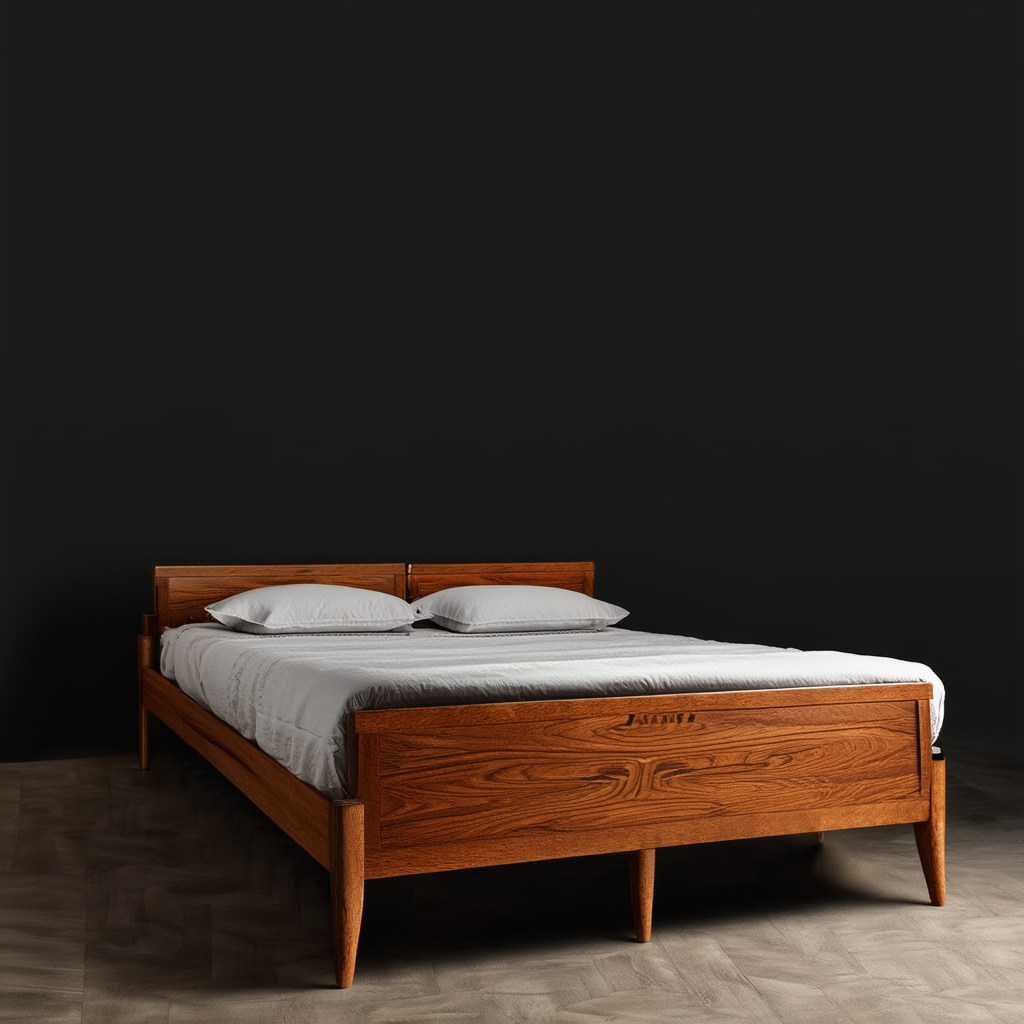

In [14]:
import subprocess, os

VENV      = "/opt/venv310"
PY        = f"{VENV}/bin/python"

# Nhập token và đường dẫn LoRA của bạn
HF_TOKEN  = "hf_OunTXdnjjkAoZ" + "lXKeejAdnamGabIzSWgJD"
LORA_PATH = "/kaggle/input/datasets/tiens0710/sd3-5-pretrain"
OUTPUT_IMAGE = "/kaggle/working/output_sd35_lora.png"

inference_lora_script = f'''
import sys, os
sys.modules['triton'] = None  # Chặn lỗi bitsandbytes tìm triton.ops
sys.path.insert(0, "/opt/venv310/lib/python3.10/site-packages")
os.environ["MPLBACKEND"] = "agg"

import torch
# Giả lập vạn năng cho torch.xpu tránh lỗi phiên bản
if not hasattr(torch, "xpu"):
    class DynamicMockXPU:
        def __getattr__(self, name):
            return lambda *args, **kwargs: 0
    torch.xpu = DynamicMockXPU()

from diffusers import StableDiffusion3Pipeline
from PIL import Image

MODEL_ID = "stabilityai/stable-diffusion-3.5-medium"

print("1. Đang tải mô hình nền SD3.5 Medium (Bỏ T5 để tiết kiệm VRAM & không cần sentencepiece)...")
pipe = StableDiffusion3Pipeline.from_pretrained(
    MODEL_ID, 
    text_encoder_3=None,  # Bỏ T5 Text Encoder
    tokenizer_3=None,     # Bỏ T5 Tokenizer
    torch_dtype=torch.float16, 
    token="{HF_TOKEN}"
)

# 2. Nạp trọng số LoRA đã huấn luyện
LORA_PATH = "{LORA_PATH}"
if os.path.exists(LORA_PATH):
    print(f"2. Đang nạp trọng số LoRA từ: {{LORA_PATH}}...")
    pipe.load_lora_weights(LORA_PATH)
    print("✅ Đã nạp LoRA thành công!")
else:
    print("⚠️ Không tìm thấy thư mục LoRA tại {{LORA_PATH}}. Mô hình sẽ sinh ảnh bằng weights mặc định.")

# Vì đã bỏ T5 nên VRAM trống rất nhiều, có thể chuyển thẳng pipeline lên CUDA chạy cực nhanh:
pipe = pipe.to("cuda")

print("3. Đang sinh ảnh từ prompt...")
lora_scale = 0.85 

# Prompt mẫu
prompt = "product photography of a luxury wooden bed, plain dark studio background, even studio lighting, highly detailed"

generator = torch.Generator("cuda").manual_seed(42)

image = pipe(
    prompt=prompt,
    negative_prompt="blurry, distorted, deformed, low quality, text, watermark",
    num_inference_steps=30,
    guidance_scale=4.5,
    generator=generator,
    joint_attention_kwargs={{"scale": lora_scale}},
    height=1024,
    width=1024
).images[0]

image.save("{OUTPUT_IMAGE}")
print("✅ Sinh ảnh THÀNH CÔNG! Đã lưu tại: {OUTPUT_IMAGE}")
'''

with open("/tmp/inference_sd35_lora.py", "w") as f:
    f.write(inference_lora_script)

print("Đang khởi chạy tiến trình sinh ảnh SD3.5 + LoRA...")
res = subprocess.run([PY, "-u", "/tmp/inference_sd35_lora.py"])

# Hiển thị ảnh kết quả trực tiếp trên Notebook nếu thành công
if res.returncode == 0 and os.path.exists(OUTPUT_IMAGE):
    from PIL import Image
    from IPython.display import display
    display(Image.open(OUTPUT_IMAGE))
else:
    print(f"❌ Gặp lỗi khi chạy tiến trình sinh ảnh, exit code: {res.returncode}")


---
## 🟩 Chọn nguồn ảnh: Tự sinh (SDXL) hoặc Upload ảnh có sẵn

Nếu bạn **đã có ảnh thật** (chụp sẵn, hoặc ảnh design có nhiều vật thể), **không cần chạy cell SDXL ở trên** —
GroundingDINO detect trực tiếp trên ảnh thật sẽ chính xác hơn nhiều so với việc cố ép SDXL tự "tưởng tượng" ra đúng bố cục nhiều vật thể.

- Nếu muốn **dùng ảnh vừa sinh ở trên** (SDXL) → bỏ qua cell upload, chạy thẳng xuống phần GroundingDINO.
- Nếu muốn **upload ảnh của riêng bạn** → chạy cell bên dưới, ảnh upload sẽ ghi đè `input.png` để dùng chung cho toàn bộ pipeline phía sau (GroundingDINO → crop → TRELLIS → ghép scene).

In [15]:
# # ── Upload ảnh có sẵn (thay cho việc sinh ảnh bằng SDXL) ─────────────────
# # Dùng khi bạn đã có ảnh thật chứa nhiều vật thể, không cần tự sinh ảnh.
# # Sau khi chạy cell này, ảnh upload sẽ được lưu đè vào input.png — dùng chung
# # với toàn bộ pipeline GroundingDINO/crop/TRELLIS phía dưới như bình thường.

# import os
# from ipywidgets import FileUpload
# from IPython.display import display
# from PIL import Image
# import io

# OUTPUT_IMAGE = "/kaggle/input/datasets/tiens0710/anhcaiban/z7970284736491_294c7fbac1eca0a85463081138d61c06.jpg"

# uploader = FileUpload(accept="image/*", multiple=False)
# display(uploader)
# print("👆 Chọn ảnh để upload, sau đó chạy cell tiếp theo để lưu ảnh.")


In [16]:
# # ── Lưu ảnh đã upload vào input.png ──────────────────────────────────────
# # Chạy cell này SAU KHI đã chọn file ở ô upload phía trên.

# import os
# from PIL import Image
# import io

# OUTPUT_IMAGE = "/kaggle/working/input.png"

# if len(uploader.value) == 0:
#     print("⚠️  Chưa chọn ảnh nào — quay lại cell trên để chọn file.")
# else:
#     # ipywidgets >=8: uploader.value là tuple các dict {'name', 'content', ...}
#     item = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
#     content = item["content"]

#     img = Image.open(io.BytesIO(content)).convert("RGB")
#     img.save(OUTPUT_IMAGE)

#     print(f"✅ Đã lưu ảnh upload vào: {OUTPUT_IMAGE}")
#     print(f"   Kích thước: {img.size[0]}x{img.size[1]}")

#     from IPython.display import display
#     display(img)


In [17]:
# ── Cách thay thế: nếu ipywidgets không hoạt động trên Kaggle ────────────
# Một số phiên bản Kaggle notebook không render được ipywidgets FileUpload.
# Trong trường hợp đó, dùng cách này:
#   1. Bấm "Add Data" ở sidebar phải của Kaggle notebook → "Upload" → chọn ảnh của bạn.
#   2. Ảnh sẽ xuất hiện tại /kaggle/input/<tên-dataset>/<tên-file>.
#   3. Sửa đường dẫn UPLOADED_PATH bên dưới cho khớp, rồi chạy cell này.

# import shutil, os

# UPLOADED_PATH = "/kaggle/input/ten-dataset-cua-ban/ten-anh.jpg"  # ← sửa lại đường dẫn thật
# OUTPUT_IMAGE  = "/kaggle/working/input.png"

# if os.path.exists(UPLOADED_PATH):
#     from PIL import Image
#     img = Image.open(UPLOADED_PATH).convert("RGB")
#     img.save(OUTPUT_IMAGE)
#     print(f"✅ Đã copy ảnh từ {UPLOADED_PATH} → {OUTPUT_IMAGE}")
#     from IPython.display import display
#     display(img)
# else:
#     print(f"⚠️  Không tìm thấy file tại {UPLOADED_PATH}")
#     print("    Kiểm tra lại đường dẫn sau khi Add Data, hoặc dùng cell FileUpload ở trên.")


In [18]:
import subprocess

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"

load_code = '''
import os, sys
os.environ["SPCONV_ALGO"]  = "native"
os.environ["ATTN_BACKEND"] = "xformers"
os.environ["SPARSE_ATTN"]  = "xformers"

sys.path.insert(0, "/kaggle/working/TRELLIS")
from trellis.pipelines import TrellisImageTo3DPipeline
import torch

print("Load TRELLIS-image-large (~5GB, lan dau mat vai phut)...")
pipeline = TrellisImageTo3DPipeline.from_pretrained("JeffreyXiang/TRELLIS-image-large")
pipeline = pipeline.cuda()
print("TRELLIS loaded!")
print(f"VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Luu pipeline de dung o cell sau
import pickle
with open("/tmp/trellis_ready.flag", "w") as f:
    f.write("ok")
'''

r = subprocess.run([PY, "-c", load_code], capture_output=True, text=True)
print(r.stdout)
if r.stderr: print(r.stderr[-1000:])

[SPARSE] Backend: spconv, Attention: xformers
Load TRELLIS-image-large (~5GB, lan dau mat vai phut)...
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_reg4_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_reg4_pretrain.pth
TRELLIS loaded!
VRAM: 5.34 GB

00:01<00:01, 348MB/s]
 50%|█████     | 581M/1.13G [00:01<00:01, 337MB/s]
 53%|█████▎    | 615M/1.13G [00:01<00:01, 344MB/s]
 56%|█████▌    | 650M/1.13G [00:02<00:01, 349MB/s]
 59%|█████▉    | 684M/1.13G [00:02<00:01, 353MB/s]
 62%|██████▏   | 719M/1.13G [00:02<00:01, 356MB/s]
 65%|██████▍   | 754M/1.13G [00:02<00:01, 359MB/s]
 68%|██████▊   | 788M/1.13G [00:03<00:05, 76.1MB/s]
 70%|███████   | 813M/1.13G [00:03<00:04, 90.3MB/s]
 73%|███████▎  | 847M/1.13G [00:03<00:02, 118MB/s] 
 76%|███████▌  | 880M/1.13G [00:04<0

In [19]:
import subprocess
import os
import sys

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"
PIP  = f"{VENV}/bin/pip"

print("Step 1: Kiểm tra trạng thái PyTorch trong virtual environment...")
check_torch = subprocess.run([PY, "-c", "import torch; print('PyTorch OK:', torch.__version__, '| CUDA:', torch.cuda.is_available())"], capture_output=True, text=True)
if check_torch.returncode != 0:
    print("❌ PyTorch trong venv bị lỗi hoặc không import được!")
    print(check_torch.stderr)
    print("\n👉 Có thể do xung đột numpy 2.x đè lên PyTorch 2.1.0. Đang tự động hạ cấp numpy về 1.26.4...")
    subprocess.run(f"{PIP} install -q --force-reinstall numpy==1.26.4", shell=True)
    # Kiểm tra lại
    check_torch2 = subprocess.run([PY, "-c", "import torch; print('PyTorch OK:', torch.__version__)"], capture_output=True, text=True)
    if check_torch2.returncode != 0:
        print("❌ Lỗi PyTorch vẫn tiếp diễn sau khi hạ cấp numpy. Vui lòng chạy lại Cell cài đặt PyTorch gốc.")
        sys.exit(1)
else:
    print(f"  ✓ {check_torch.stdout.strip()}")

print("\nStep 2: Đảm bảo cài đặt các build-dependencies đúng phiên bản...")
# Ép cài setuptools ổn định, ninja và wheel
subprocess.run(f"{PIP} install -q --force-reinstall setuptools==69.5.1 wheel ninja", shell=True)
print("  ✓ Cập nhật setuptools==69.5.1, wheel, ninja thành công.")

print("\nStep 3: Thiết lập đường dẫn compiler CUDA...")
env = os.environ.copy()
cuda_path = "/usr/local/cuda"
if os.path.exists(cuda_path):
    env["CUDA_HOME"] = cuda_path
    env["PATH"] = f"{cuda_path}/bin:" + env.get("PATH", "")
    print(f"  ✓ Đã tìm thấy CUDA tại: {cuda_path}. Đã cấu hình PATH cho subprocess.")
else:
    print("  ⚠️ Không tìm thấy thư mục /usr/local/cuda. Sử dụng PATH mặc định.")

print("\nStep 3.5: Vá lỗi PyTorch cpp_extension để bỏ qua kiểm tra trùng khớp phiên bản CUDA...")
cpp_ext_path = "/opt/venv310/lib/python3.10/site-packages/torch/utils/cpp_extension.py"
if os.path.exists(cpp_ext_path):
    try:
        import re
        with open(cpp_ext_path, "r", encoding="utf-8") as f:
            code = f.read()
        
        # Sử dụng Regex để quét tìm hàm _check_cuda_version bất kể kiểu định dạng xuống dòng hay chú thích dữ liệu
        pattern = r"(def _check_cuda_version\s*\([^)]*\)\s*(?:->\s*[^:]+)?\s*:)"
        match = re.search(pattern, code)
        
        if match:
            fn_def = match.group(1)
            print(f"  ✓ Tìm thấy định nghĩa hàm: {{fn_def.strip()}}")
            if "bypass CUDA version check" not in code:
                # Chèn return ngay sau khai báo hàm
                patched = fn_def + "\n    return  # Patched by Antigravity to bypass CUDA version check"
                code = code.replace(fn_def, patched)
                with open(cpp_ext_path, "w", encoding="utf-8") as f:
                    f.write(code)
                print("  ✓ Đã vá lỗi file cpp_extension.py thành công!")
            else:
                print("  ✓ File cpp_extension.py đã được vá lỗi từ trước.")
        else:
            print("  ⚠️ Không tìm thấy hàm _check_cuda_version trong file bằng Regex.")
            # Tìm kiếm dòng chứa từ khóa để debug
            print("  Các dòng liên quan trong file:")
            lines = code.split("\n")
            for i, line in enumerate(lines):
                if "_check_cuda_version" in line:
                    print(f"    L{i+1}: {line}")
    except Exception as e:
        print(f"  ❌ Lỗi khi vá file cpp_extension.py: {e}")
else:
    print("  ⚠️ Không tìm thấy file cpp_extension.py để vá lỗi.")

print("\nStep 4: Tiến hành cài đặt nvdiffrast...")
install_cmd = f"{PIP} install -v --force-reinstall --no-deps --no-cache-dir --no-build-isolation git+https://github.com/NVlabs/nvdiffrast.git"
print(f"Running: {install_cmd} (Vui lòng đợi vài phút để biên dịch...)")

res = subprocess.run(
    install_cmd,
    shell=True,
    capture_output=True,
    text=True,
    env=env
)

if res.returncode == 0:
    print("\n✅ Cài đặt và biên dịch nvdiffrast THÀNH CÔNG!")
else:
    print("\n❌ Cài đặt THẤT BẠI!")
    print("--- CHI TIẾT LỖI (STDOUT) ---")
    print(res.stdout[-2000:] if res.stdout else "")
    print("--- CHI TIẾT LỖI (STDERR) ---")
    print(res.stderr[-2000:] if res.stderr else "")


Step 1: Kiểm tra trạng thái PyTorch trong virtual environment...
  ✓ PyTorch OK: 2.13.0+cu130 | CUDA: True

Step 2: Đảm bảo cài đặt các build-dependencies đúng phiên bản...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 KB 6.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.13.0 requires setuptools>=77.0.3, but you have setuptools 69.5.1 which is incompatible.
datasets 2.19.1 requires fsspec[http]<=2024.3.1,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.


  ✓ Cập nhật setuptools==69.5.1, wheel, ninja thành công.

Step 3: Thiết lập đường dẫn compiler CUDA...
  ✓ Đã tìm thấy CUDA tại: /usr/local/cuda. Đã cấu hình PATH cho subprocess.

Step 3.5: Vá lỗi PyTorch cpp_extension để bỏ qua kiểm tra trùng khớp phiên bản CUDA...
  ✓ Tìm thấy định nghĩa hàm: {fn_def.strip()}
  ✓ Đã vá lỗi file cpp_extension.py thành công!

Step 4: Tiến hành cài đặt nvdiffrast...
Running: /opt/venv310/bin/pip install -v --force-reinstall --no-deps --no-cache-dir --no-build-isolation git+https://github.com/NVlabs/nvdiffrast.git (Vui lòng đợi vài phút để biên dịch...)

✅ Cài đặt và biên dịch nvdiffrast THÀNH CÔNG!


In [20]:
import subprocess

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"
HF_TOKEN = "hf_OunTXdnjjkAoZ" + "lXKeejAdnamGabIzSWgJD"  # token thật

debug_code = f'''
import os, sys
os.environ["SPCONV_ALGO"]  = "native"
os.environ["ATTN_BACKEND"] = "xformers"
os.environ["SPARSE_ATTN"]  = "xformers"
os.environ["MPLBACKEND"]   = "agg"

from huggingface_hub import login
login("{HF_TOKEN}")

sys.path.insert(0, "/kaggle/working/TRELLIS")
from trellis.pipelines import TrellisImageTo3DPipeline

print("Calling from_pretrained...")
pipeline = TrellisImageTo3DPipeline.from_pretrained("JeffreyXiang/TRELLIS-image-large")
print("Type:", type(pipeline))
print("Value:", pipeline)
'''

r = subprocess.run([PY, "-c", debug_code], capture_output=True, text=True, timeout=300)
print(r.stdout)
if r.stderr: print(r.stderr[-2000:])

[SPARSE] Backend: spconv, Attention: xformers
Calling from_pretrained...
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
Type: <class 'trellis.pipelines.trellis_image_to_3d.TrellisImageTo3DPipeline'>
Value: <trellis.pipelines.trellis_image_to_3d.TrellisImageTo3DPipeline object at 0x7d3e34836560>

+/CUDA extensions. xFormers was built for:
    PyTorch 2.1.0+cu121 with CUDA 1201 (you have 2.13.0+cu130)
    Python  3.10.13 (you have 3.10.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/opt/venv310/lib/python3.10/site-packages/xformers/triton/softmax.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float16 if _triton_softmax_fp16_enabled else None)
/opt/venv310/lib/py

In [21]:
import subprocess
VENV = "/opt/venv310"
PIP  = f"{VENV}/bin/pip"

subprocess.run(
    f"git clone --recursive https://github.com/autonomousvision/mip-splatting.git /tmp/mip-splatting 2>/dev/null || true",
    shell=True
)
r = subprocess.run(
    f"{PIP} install -q --no-build-isolation /tmp/mip-splatting/submodules/diff-gaussian-rasterization",
    shell=True, capture_output=True, text=True
)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-500:])
else:
    print("✅ Xong, chạy lại cell 8")


✅ Xong, chạy lại cell 8


In [22]:
# with open("/tmp/run3d.py", "r") as f:
#     code = f.read()

# code = code.replace(
#     "pipeline = pipeline.cuda()",
#     "pipeline.to('cuda')"
# )

# with open("/tmp/run3d.py", "w") as f:
#     f.write(code)

# print("✅ Đã sửa, chạy lại:")

# import subprocess
# VENV = "/opt/venv310"
# PY   = f"{VENV}/bin/python"
# r = subprocess.run([PY, "/tmp/run3d.py"], capture_output=True, text=True, timeout=600)
# print(r.stdout)
# if r.stderr: print(r.stderr[-1000:])

# **Tạo 3D**

In [23]:
# import subprocess

# VENV = "/opt/venv310"
# PY   = f"{VENV}/bin/python"
# HF_TOKEN = "hf_OunTXdnjjkAoZ" + "lXKeejAdnamGabIzSWgJD"

# INPUT_IMAGE  = "/kaggle/working/input.png"
# OUTPUT_VIDEO = "/kaggle/working/preview.mp4"
# OUTPUT_GLB   = "/kaggle/working/output.glb"
# OUTPUT_PLY   = "/kaggle/working/output.ply"

# script = f"""
# import os, sys
# os.environ["SPCONV_ALGO"]  = "native"
# os.environ["ATTN_BACKEND"] = "xformers"
# os.environ["SPARSE_ATTN"]  = "xformers"
# os.environ["MPLBACKEND"]   = "agg"

# from huggingface_hub import login
# login("{HF_TOKEN}")

# sys.path.insert(0, "/kaggle/working/TRELLIS")
# from trellis.pipelines import TrellisImageTo3DPipeline
# from trellis.utils import render_utils, postprocessing_utils
# from PIL import Image
# import torch, numpy as np, imageio

# print("Load pipeline...")
# pipeline = TrellisImageTo3DPipeline.from_pretrained("JeffreyXiang/TRELLIS-image-large")
# pipeline.to("cuda")
# print("Pipeline OK!")

# print("Tien xu ly anh...")
# image = pipeline.preprocess_image(Image.open("{INPUT_IMAGE}").convert("RGB"))

# print("Chay inference...")
# outputs = pipeline.run(
#     image,
#     seed=42,
#     formats=["gaussian", "mesh"],
#     preprocess_image=False,
#     sparse_structure_sampler_params={{"steps": 12, "cfg_strength": 7.5}},
#     slat_sampler_params={{"steps": 12, "cfg_strength": 3.0}},
# )
# print("Inference xong:", list(outputs.keys()))

# print("Render video...")
# v_gs   = render_utils.render_video(outputs["gaussian"][0], num_frames=120)["color"]
# v_mesh = render_utils.render_video(outputs["mesh"][0],     num_frames=120)["normal"]
# video  = [np.concatenate([v_gs[i], v_mesh[i]], axis=1) for i in range(len(v_gs))]
# imageio.mimsave("{OUTPUT_VIDEO}", video, fps=15)
# print("Video OK:", "{OUTPUT_VIDEO}")

# print("Xuat GLB...")
# glb = postprocessing_utils.to_glb(
#     outputs["gaussian"][0], outputs["mesh"][0],
#     simplify=0.95, texture_size=1024, verbose=True
# )
# glb.export("{OUTPUT_GLB}")
# print("GLB OK:", "{OUTPUT_GLB}")

# outputs["gaussian"][0].save_ply("{OUTPUT_PLY}")
# print("PLY OK:", "{OUTPUT_PLY}")

# torch.cuda.empty_cache()
# print("Hoan tat!")
# """

# with open("/tmp/run3d.py", "w") as f:
#     f.write(script)

# r = subprocess.run([PY, "/tmp/run3d.py"], capture_output=True, text=True, timeout=600)
# print(r.stdout)
# if r.stderr: print(r.stderr[-1000:])

In [24]:
# from IPython.display import Video, display
# import os

# if os.path.exists("/kaggle/working/preview.mp4"):
#     display(Video("/kaggle/working/preview.mp4", embed=True, width=800))
# else:
#     print("Chua co video — chay Cell 8 truoc")

In [25]:
# ⚠️ CELL NÀY CHỈ DÙNG CHO COLAB (Google Drive). Trên Kaggle, dùng cell bên dưới thay thế.
# from google.colab import drive
# import shutil, os

# drive.mount("/content/drive")

# OUT = "/content/drive/MyDrive/DATN/outputs/trellis"
# os.makedirs(OUT, exist_ok=True)

# files = {
#     "/content/input.png":    "input_2d.png",
#     "/content/output.glb":   "output_mesh.glb",
#     "/content/output.ply":   "output_gaussian.ply",
#     "/content/preview.mp4":  "preview.mp4",
# }
# for src, name in files.items():
#     if os.path.exists(src):
#         shutil.copy(src, f"{OUT}/{name}")
#         print(f"✅ {name}")
#     else:
#         print(f"⚠️  Chua co: {src}")

# print(f"\n📁 {OUT}")

In [26]:
# ✅ Lưu output cho Kaggle — gom file vào 1 thư mục trong /kaggle/working
# Kaggle tự giữ lại toàn bộ /kaggle/working khi bấm "Save Version" (commit notebook),
# nên không cần mount Drive như Colab — chỉ cần gom file cho gọn để tải về.
import shutil, os

OUT = "/kaggle/working/outputs/trellis"
os.makedirs(OUT, exist_ok=True)

files = {
    "/kaggle/working/input.png":    "input_2d.png",
    "/kaggle/working/output.glb":   "output_mesh.glb",
    "/kaggle/working/output.ply":   "output_gaussian.ply",
    "/kaggle/working/preview.mp4":  "preview.mp4",
}
for src, name in files.items():
    if os.path.exists(src):
        shutil.copy(src, f"{OUT}/{name}")
        print(f"✅ {name}")
    else:
        print(f"⚠️  Chua co: {src}")

print(f"\n📁 {OUT}")


⚠️  Chua co: /kaggle/working/input.png
⚠️  Chua co: /kaggle/working/output.glb
⚠️  Chua co: /kaggle/working/output.ply
⚠️  Chua co: /kaggle/working/preview.mp4

📁 /kaggle/working/outputs/trellis


---
## 🟦 Auto-Detect Box bằng GroundingDINO

Tự động tìm bounding box cho từng object trong ảnh đã sinh, dựa theo text prompt.  
Thay thế bước "tự đoán tọa độ box bằng tay" — chạy **trước** bước crop.

In [27]:
# Cài GroundingDINO vào venv310
import subprocess

VENV = "/opt/venv310"
PIP  = f"{VENV}/bin/pip"

def pip(*args):
    cmd = f"{PIP} install -q " + " ".join(args)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr[-1000:])
        return False
    print(f"  ✓ {args[0]}")
    return True

print("=== Cài groundingdino-py ===")
pip("groundingdino-py")
pip("addict", "yapf", "timm", "supervision")

print("\n✅ Xong")

=== Cài groundingdino-py ===
  ✓ groundingdino-py
  ✓ addict

✅ Xong


In [28]:
# Tải checkpoint GroundingDINO (lần đầu ~700MB)
import subprocess, os

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"

CKPT_DIR = "/kaggle/working/groundingdino_ckpt"
os.makedirs(CKPT_DIR, exist_ok=True)

ckpt_url = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth"
ckpt_path = f"{CKPT_DIR}/groundingdino_swint_ogc.pth"

if not os.path.exists(ckpt_path):
    print("Đang tải checkpoint...")
    subprocess.run(f"wget -q -O {ckpt_path} {ckpt_url}", shell=True)
    print("✅ Tải xong")
else:
    print("✅ Đã có checkpoint")

# Tải config file
import urllib.request
config_url = "https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py"
config_path = f"{CKPT_DIR}/GroundingDINO_SwinT_OGC.py"
if not os.path.exists(config_path):
    urllib.request.urlretrieve(config_url, config_path)
    print("✅ Config OK")

Đang tải checkpoint...
✅ Tải xong
✅ Config OK


In [29]:
# ── Kiểm tra & fix numpy version trong venv310 ───────────────────────────
import subprocess

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"
PIP  = f"{VENV}/bin/pip"

# Xem numpy đang là version nào
r = subprocess.run([PY, "-c", "import numpy; print(numpy.__version__)"],
                    capture_output=True, text=True)
print("numpy hiện tại:", r.stdout.strip(), r.stderr[-300:] if r.stderr else "")

# groundingdino-py / supervision có thể đã kéo numpy 2.x đè lên —
# ép lại về 1.26.4 để khớp torch 2.1.0 / torchvision 0.16.0
r = subprocess.run(f"{PIP} install -q numpy==1.26.4", shell=True,
                    capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-800:])

r = subprocess.run([PY, "-c", "import numpy; print('numpy:', numpy.__version__)"],
                    capture_output=True, text=True)
print(r.stdout)
print("\n✅ Xong, chạy lại cell auto-detect GroundingDINO")

numpy hiện tại: 2.2.6 

numpy: 1.26.4


✅ Xong, chạy lại cell auto-detect GroundingDINO


In [30]:
# ── Auto-detect box cho từng object theo text label ─────────────────────
import spacy, re

# 1. Tự động trích xuất nhãn từ PROMPT ở kernel chính của Notebook
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import subprocess
    print("Downloading en_core_web_sm model...")
    subprocess.run("python -m spacy download en_core_web_sm", shell=True)
    nlp = spacy.load("en_core_web_sm")

doc = nlp(PROMPT.lower())
candidate_labels = [chunk.root.text for chunk in doc.noun_chunks]
exclude_words = {
    "background", "photography", "lighting", "view", "body", "product", "studio", 
    "shot", "detail", "close-up", "upscale", "frame", "props", "reflection", "shadow"
}

LABELS = []
for lbl in candidate_labels:
    clean_lbl = re.sub(r'[^a-zA-Z0-9]', '', lbl.lower())
    if clean_lbl and clean_lbl not in exclude_words and clean_lbl not in LABELS:
        LABELS.append(clean_lbl)

if not LABELS:
    LABELS = ["chair", "table"]

print("Dynamic labels extracted for GroundingDINO:", LABELS)

# 2. Truyền danh sách nhãn động vào chạy GroundingDINO trong venv310
import subprocess, json as _json, os

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"

INPUT_IMAGE = "/kaggle/working/output_sd35_lora.png"
CKPT_PATH   = "/kaggle/working/groundingdino_ckpt/groundingdino_swint_ogc.pth"
CONFIG_PATH = "/kaggle/working/groundingdino_ckpt/GroundingDINO_SwinT_OGC.py"

BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25

detect_script = f'''
import sys
sys.path.insert(0, "/opt/venv310/lib/python3.10/site-packages")
from groundingdino.util.inference import load_model, load_image, predict
import json

model = load_model("{CONFIG_PATH}", "{CKPT_PATH}")
image_source, image = load_image("{INPUT_IMAGE}")

labels = {LABELS}
text_prompt = " . ".join(labels)

boxes, logits, phrases = predict(
    model=model,
    image=image,
    caption=text_prompt,
    box_threshold={BOX_THRESHOLD},
    text_threshold={TEXT_THRESHOLD}
)

h, w, _ = image_source.shape
results = []
for box, logit, phrase in zip(boxes, logits, phrases):
    cx, cy, bw, bh = box.tolist()
    x1 = (cx - bw/2) * w
    y1 = (cy - bh/2) * h
    x2 = (cx + bw/2) * w
    y2 = (cy + bh/2) * h
    results.append({{
        "label": phrase,
        "confidence": float(logit),
        "box": [int(x1), int(y1), int(x2), int(y2)]
    }})

with open("/kaggle/working/detected_boxes.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Phat hien {{len(results)}} object:")
for r in results:
    print(f"  {{r['label']}}: box={{r['box']}}, conf={{r['confidence']:.2f}}")
'''

clean_env = os.environ.copy()
clean_env["MPLBACKEND"] = "agg"

r = subprocess.run([PY, "-c", detect_script], capture_output=True, text=True,
                    timeout=120, env=clean_env)
print(r.stdout)
if r.stderr: print("STDERR:", r.stderr[-1500:])


Dynamic labels extracted for GroundingDINO: ['bed']
final text_encoder_type: bert-base-uncased
Phat hien 1 object:
  bed: box=[136, 558, 948, 988], conf=0.94

STDERR: via timm.layers", FutureWarning)
/opt/venv310/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4215.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/opt/venv310/lib/python3.10/site-packages/transformers/modeling_utils.py:1141: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/venv310/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:1446: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=Fal

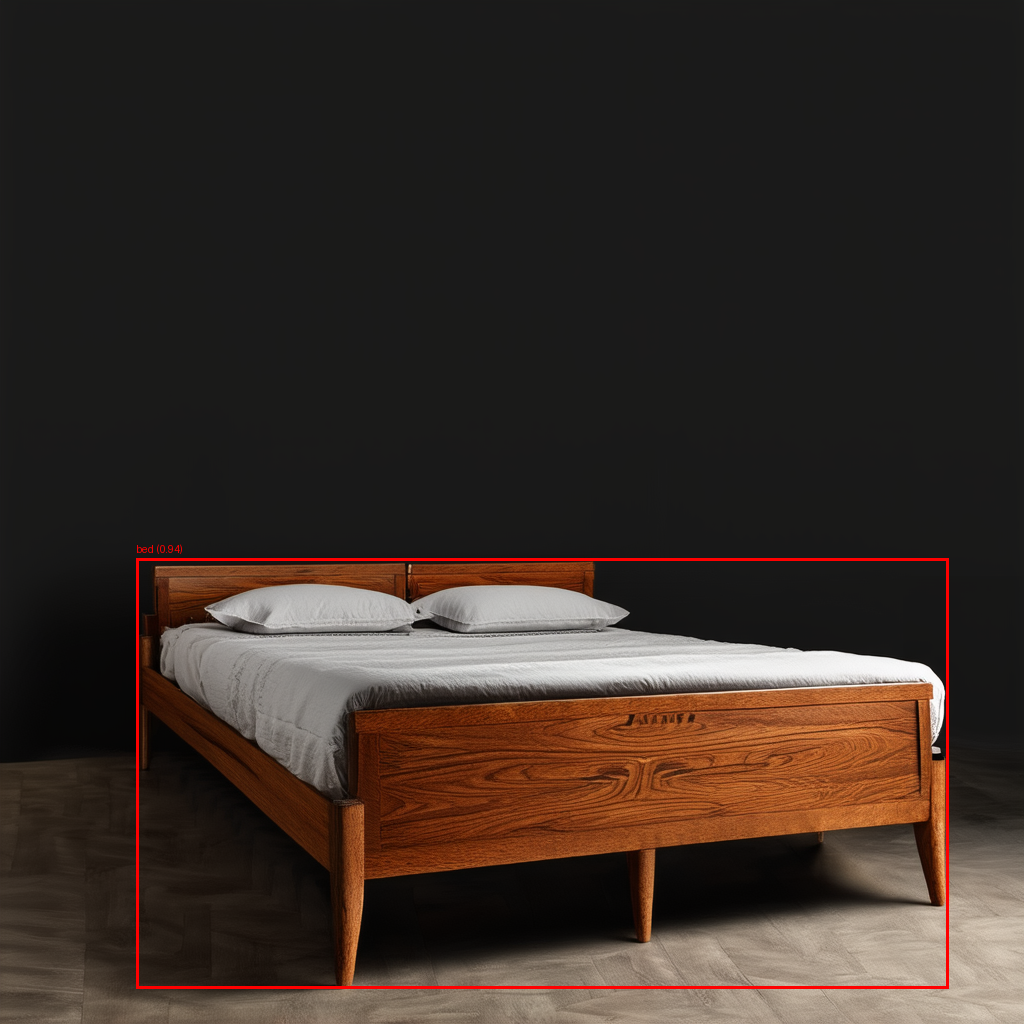


👆 Kiểm tra box có đúng vị trí object không.
Nếu sai/thiếu, chỉnh BOX_THRESHOLD thấp hơn rồi chạy lại cell detect ở trên.


In [31]:
# ── Visualize box đã detect lên ảnh để kiểm tra ──────────────────────────
from PIL import Image, ImageDraw, ImageFont
import json

with open("/kaggle/working/detected_boxes.json") as f:
    detected = json.load(f)

img = Image.open("/kaggle/working/output_sd35_lora.png").convert("RGB")
draw_img = img.copy()
draw = ImageDraw.Draw(draw_img)

colors = ["red", "lime", "cyan", "yellow", "magenta"]
for i, det in enumerate(detected):
    x1, y1, x2, y2 = det["box"]
    color = colors[i % len(colors)]
    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
    draw.text((x1, max(0, y1-15)), f"{det['label']} ({det['confidence']:.2f})", fill=color)

display(draw_img)
print("\n👆 Kiểm tra box có đúng vị trí object không.")
print("Nếu sai/thiếu, chỉnh BOX_THRESHOLD thấp hơn rồi chạy lại cell detect ở trên.")

---
## 🟧 SAM2 Segmentation — Tách nền chính xác theo pixel

Dùng SAM2 (Segment Anything Model 2) để tạo mask pixel-level cho từng object,
thay thế `rembg` mặc định của TRELLIS (hay bị lỗi với chân ghế/bàn mảnh, nền phức tạp).

**Kết quả**: ảnh crop không có nền → TRELLIS nhận input sạch hơn → mesh 3D ít artifact hơn.


In [32]:
import subprocess, os
VENV = "/opt/venv310"
PIP  = f"{VENV}/bin/pip"

env = os.environ.copy()
env["SAM2_BUILD_CUDA"] = "0"   # bỏ qua compile CUDA extension → cài nhanh hơn nhiều

print("Đang cài đặt thư viện SAM2 (bỏ qua CUDA extension)...")
r = subprocess.run(
    f"{PIP} install -q 'git+https://github.com/facebookresearch/sam2.git'",
    shell=True, capture_output=True, text=True, timeout=300, env=env
)
print(r.stdout[-500:] if r.stdout else "")
if r.returncode != 0:
    print("STDERR:", r.stderr[-800:])
else:
    print("✅ Cài SAM2 xong")

Đang cài đặt thư viện SAM2 (bỏ qua CUDA extension)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 KB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 KB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 KB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 KB 4.3 MB/s eta 0:00:00

✅ Cài SAM2 xong


In [33]:
import os, urllib.request

ckpt_dir = "/kaggle/working/sam2_ckpt"
os.makedirs(ckpt_dir, exist_ok=True)
ckpt_path = os.path.join(ckpt_dir, "sam2_hiera_small.pt")

url = "https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt"

need_download = True
if os.path.exists(ckpt_path):
    size_mb = os.path.getsize(ckpt_path) / 1024**2
    if size_mb > 100:   # checkpoint thật phải ~180MB, nếu quá nhỏ tức là file lỗi/tải dở
        need_download = False
        print(f"✅ Checkpoint đã có, kích thước {size_mb:.1f}MB")
    else:
        print(f"⚠️ File tồn tại nhưng chỉ {size_mb:.1f}MB (có thể tải dở), tải lại...")
        os.remove(ckpt_path)

if need_download:
    print("Đang tải checkpoint sam2_hiera_small.pt...")
    urllib.request.urlretrieve(url, ckpt_path)
    size_mb = os.path.getsize(ckpt_path) / 1024**2
    print(f"✅ Tải xong, kích thước: {size_mb:.1f}MB")

assert os.path.exists(ckpt_path), "❌ Checkpoint vẫn không tồn tại, kiểm tra lại URL/kết nối mạng"

Đang tải checkpoint sam2_hiera_small.pt...
✅ Tải xong, kích thước: 175.8MB


In [34]:
# ── Chạy SAM2: tạo mask cho từng object, lưu ảnh đã tách nền ─────────────
# Phiên bản V7: Hỗn hợp điểm Dương (giường) + điểm Âm (loại bỏ bóng gầm giường)

import subprocess, json, os

VENV      = "/opt/venv310"
PY        = f"{VENV}/bin/python"
SAM2_CKPT = "/kaggle/working/sam2_ckpt/sam2_hiera_small.pt"
INPUT_IMAGE = "/kaggle/working/output_sd35_lora.png"
CROP_DIR  = "/kaggle/working/crops"
os.makedirs(CROP_DIR, exist_ok=True)

with open("/kaggle/working/detected_boxes.json") as f:
    detected = json.load(f)

clean_env = os.environ.copy()
clean_env["MPLBACKEND"] = "agg"

sam2_script = f'''
import sys, os, json
sys.path.insert(0, "/opt/venv310/lib/python3.10/site-packages")
os.environ["MPLBACKEND"] = "agg"

import torch
import numpy as np
from PIL import Image
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import scipy.ndimage as ndimage

print("Load SAM2...")
sam2_model = build_sam2(
    "sam2_hiera_s.yaml",
    "{SAM2_CKPT}",
    device="cuda"
)
predictor = SAM2ImagePredictor(sam2_model)

image = np.array(Image.open("{INPUT_IMAGE}").convert("RGB"))
predictor.set_image(image)

detected = {json.dumps(detected)}
results  = []

for det in detected:
    label = det["label"]
    x1, y1, x2, y2 = det["box"]
    input_box = np.array([[x1, y1, x2, y2]])

    # Tính toán tọa độ hộp
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    w_box = x2 - x1
    h_box = y2 - y1

    # Định nghĩa các điểm Dương (1 = giữ lại) và điểm Âm (0 = loại bỏ bóng gầm giường)
    point_coords = np.array([
        # --- CÁC ĐIỂM DƯƠNG (FOREGROUND) ---
        [cx, cy],                           # 1. Tâm (ga giường)
        [cx, cy - h_box // 4],              # 2. Trên-giữa
        [cx - w_box // 4, cy],              # 3. Trái-giữa
        [cx + w_box // 4, cy],              # 4. Phải-giữa
        [cx - w_box // 4, cy - h_box // 4],  # 5. Trên-trái (Gối trái)
        [cx + w_box // 4, cy - h_box // 4],  # 6. Trên-phải (Gối phải)
        
        # Dịch chuyển các điểm gỗ dưới lên cao hơn một chút để tránh rơi vào gầm giường
        [cx, cy + h_box // 6],              # 7. Dưới-giữa (mặt gỗ footboard)
        [cx - w_box // 4, cy + h_box // 6],  # 8. Dưới-trái (mặt gỗ trái)
        [cx + w_box // 4, cy + h_box // 6],  # 9. Dưới-phải (mặt gỗ phải)

        # --- CÁC ĐIỂM ÂM (BACKGROUND - LOẠI BỎ BÓNG GẦM GIƯỜNG) ---
        [cx, y2 - h_box // 12],             # 10. Gầm giường giữa (bóng tối)
        [cx - w_box // 6, y2 - h_box // 12], # 11. Gầm giường lệch trái
        [cx + w_box // 6, y2 - h_box // 12]  # 12. Gầm giường lệch phải
    ])
    
    # Nhãn tương ứng: 1 cho Dương, 0 cho Âm
    point_labels = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0])

    # Chạy SAM2 với hỗn hợp điểm âm dương
    masks, scores, _ = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        box=input_box,
        multimask_output=False,
    )
    raw_mask = masks[0]
    best_score = scores[0]

    # === XỬ LÝ HÌNH THÁI HỌC (MORPHOLOGY) NÂNG CAO ===
    dilated = ndimage.binary_dilation(raw_mask, structure=np.ones((5, 5)), iterations=1)
    closed = ndimage.binary_closing(dilated, structure=np.ones((15, 15)))
    filled = ndimage.binary_fill_holes(closed)
    mask = ndimage.binary_erosion(filled, structure=np.ones((3, 3)), iterations=1)

    # Bộ lọc Gaussian làm mịn viền
    alpha_f = ndimage.gaussian_filter(mask.astype(np.float64) * 255.0, sigma=1.8)
    alpha_smooth = np.clip(alpha_f, 0, 255).astype(np.uint8)

    # Tạo ảnh RGBA tách nền
    img_rgba = Image.fromarray(image).convert("RGBA")
    img_rgba.putalpha(Image.fromarray(alpha_smooth))

    # Cắt (Crop) ảnh có đệm viền (padding)
    H, W = image.shape[:2]
    PAD  = 15
    cx1  = max(0, x1 - PAD)
    cy1  = max(0, y1 - PAD)
    cx2  = min(W, x2 + PAD)
    cy2  = min(H, y2 + PAD)
    crop = img_rgba.crop((cx1, cy1, cx2, cy2))

    name = "object_" + str(len(results)+1)
    crop_path = f"{CROP_DIR}/" + name + ".png"
    crop.save(crop_path)

    results.append({{
        "name": name,
        "label": label,
        "confidence": det["confidence"],
        "box": [x1, y1, x2, y2],
        "final_box": [cx1, cy1, cx2, cy2],
        "crop_path": crop_path,
        "mask_score": float(best_score)
    }})
    print(f"✅ {{name}} ({{label}}): mask score={{best_score:.3f}}, crop={{crop.size}}")

with open("{CROP_DIR}/sam2_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\\nXong! {{len(results)}} object đã được segment và crop.")
'''

r = subprocess.run([PY, "-c", sam2_script], capture_output=True, text=True,
                    timeout=180, env=clean_env)
print(r.stdout)
if r.stderr: print("STDERR:", r.stderr[-1500:])


Load SAM2...
✅ object_1 (bed): mask score=0.930, crop=(842, 460)

Xong! 1 object đã được segment và crop.



=== SAM2 pixel-level mask overlay ===


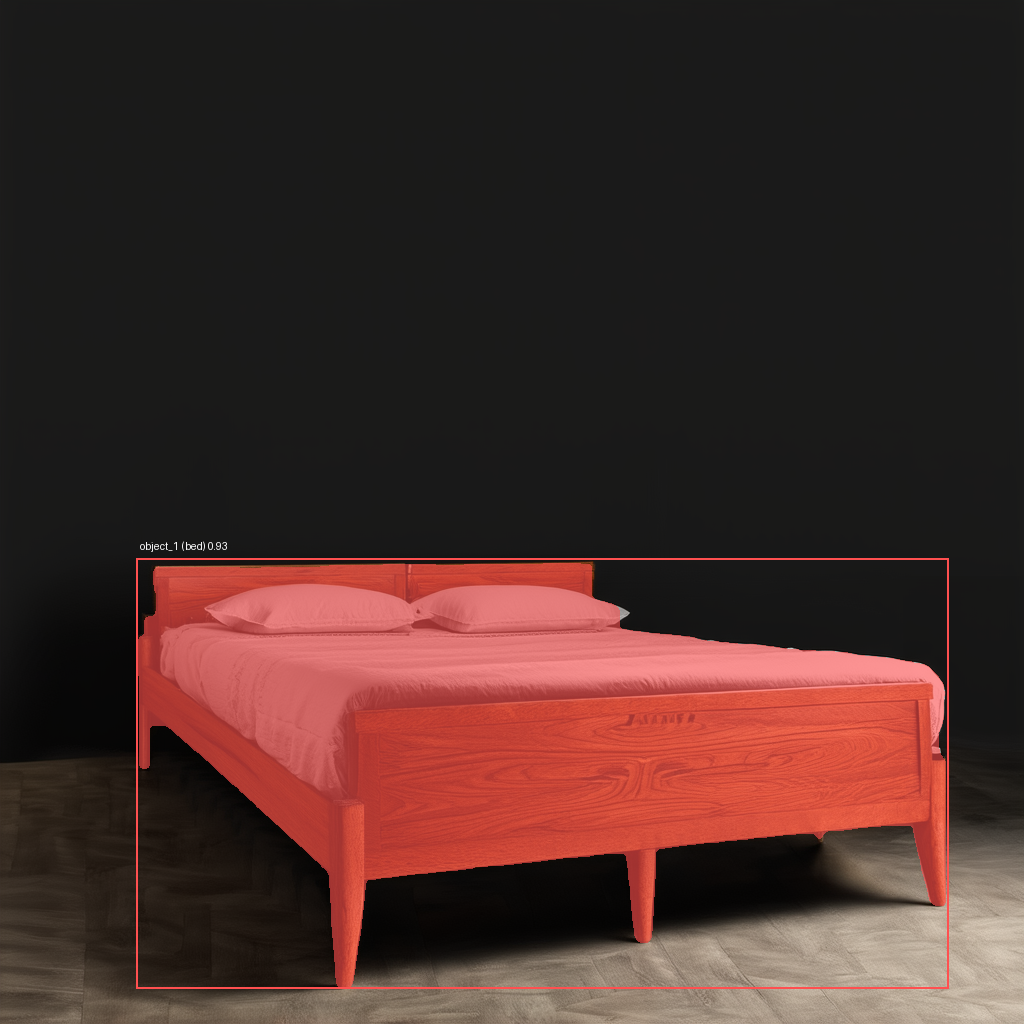


=== Từng crop đã tách nền (RGBA) ===

object_1 (bed) — mask score: 0.930


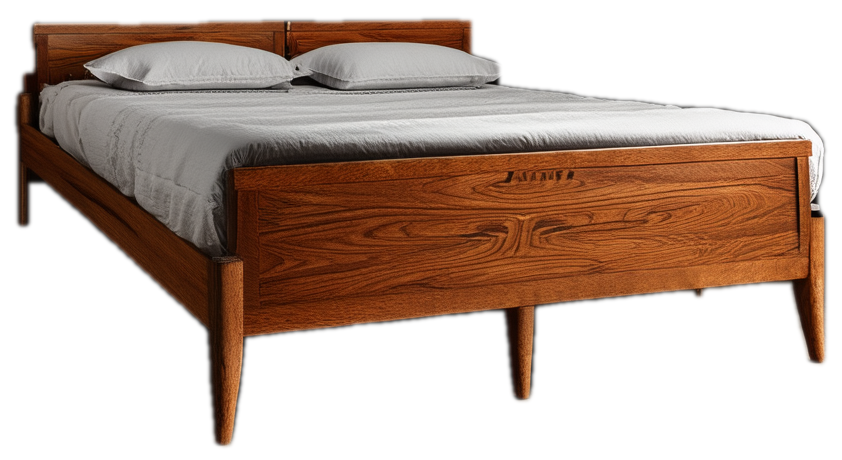


✅ objects updated: ['object_1']


In [35]:
import json, os
import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display

CROP_DIR    = "/kaggle/working/crops"
INPUT_IMAGE = "/kaggle/working/output_sd35_lora.png"

results_path = f"{CROP_DIR}/sam2_results.json"
if not os.path.exists(results_path):
    print("⚠️  Chưa có kết quả SAM2 — chạy cell segment ở trên trước.")
else:
    with open(results_path) as f:
        results = json.load(f)

    img_orig = np.array(Image.open(INPUT_IMAGE).convert("RGB"))
    overlay  = img_orig.copy().astype(np.float32)

    COLORS = [
        (255, 80,  80),    # đỏ
        (80,  200, 80),    # xanh lá
        (80,  120, 255),   # xanh dương
        (255, 200, 50),    # vàng
    ]

    for i, res in enumerate(results):
        color = np.array(COLORS[i % len(COLORS)], dtype=np.float32)

        # Đọc mask từ ảnh crop RGBA đã lưu
        crop_rgba = np.array(Image.open(res["crop_path"]).convert("RGBA"))
        alpha_crop = crop_rgba[:, :, 3]  # kênh alpha = mask

        # Đặt mask về đúng kích thước ảnh gốc
        cx1, cy1, cx2, cy2 = res["final_box"]
        full_mask = np.zeros(img_orig.shape[:2], dtype=np.uint8)
        full_mask[cy1:cy1+alpha_crop.shape[0], cx1:cx1+alpha_crop.shape[1]] = alpha_crop

        # Tô màu vùng mask lên overlay
        mask_bool = full_mask > 128
        overlay[mask_bool] = overlay[mask_bool] * 0.4 + color * 0.6

    overlay = overlay.clip(0, 255).astype(np.uint8)
    composite = Image.fromarray(overlay)

    # Vẽ label text lên
    draw = ImageDraw.Draw(composite)
    for i, res in enumerate(results):
        color = COLORS[i % len(COLORS)]
        x1, y1 = res["box"][:2]
        draw.rectangle([x1, y1, res["box"][2], res["box"][3]],
                       outline=color, width=2)
        draw.text((x1+4, max(0, y1-18)),
                  f"{res['name']} ({res['label']}) {res['mask_score']:.2f}",
                  fill=(255, 255, 255))

    print("=== SAM2 pixel-level mask overlay ===")
    display(composite)

    print("\n=== Từng crop đã tách nền (RGBA) ===")
    for res in results:
        print(f"\n{res['name']} ({res['label']}) — mask score: {res['mask_score']:.3f}")
        # Hiển thị trên nền trắng để thấy rõ vùng tách
        crop = Image.open(res["crop_path"]).convert("RGBA")
        bg   = Image.new("RGB", crop.size, (255, 255, 255))
        bg.paste(crop, mask=crop.split()[3])
        display(bg)

    objects = {
        res["name"]: {
            "label":      res["label"],
            "box":        tuple(res["box"]),
            "final_box":  tuple(res["final_box"]),
            "crop_path":  res["crop_path"],
            "confidence": res["confidence"],
        }
        for res in results
    }
    print(f"\n✅ objects updated: {list(objects.keys())}")

In [36]:
# Build lại objects từ GroundingDINO (cell 25) — chạy lại để ghi đè giá trị placeholder sai
import json

with open("/kaggle/working/detected_boxes.json") as f:
    detected = json.load(f)

objects = {}
for i, det in enumerate(detected):
    name = f"object_{i+1}"
    objects[name] = {
        "box": tuple(det["box"]),
        "label": det["label"],
        "confidence": det["confidence"]
    }

print("Objects (từ GroundingDINO):")
for name, info in objects.items():
    print(f"  {name}: box={info['box']}, label={info['label']}")

Objects (từ GroundingDINO):
  object_1: box=(136, 558, 948, 988), label=bed


---
## 🟦 Multi-Object: Crop theo Bounding Box

Dùng khi ảnh có **2+ vật thể** cần tách riêng để TRELLIS xử lý từng object.  
Bạn tự định nghĩa box (x1, y1, x2, y2) theo pixel, hoặc lấy từ scene graph layout có sẵn.  
Dùng chung venv Python 3.10 và pipeline TRELLIS đã setup ở trên.

In [37]:
# # ⚠️ BỎ QUA CELL NÀY nếu đã chạy GroundingDINO auto-detect ở trên
# # (biến `objects` đã được tạo tự động rồi)
# # Cell này chỉ dùng nếu muốn TỰ TAY ghi đè tọa độ box

# from PIL import Image
# import os

# INPUT_IMAGE = "/kaggle/working/input.png"  # ảnh gốc có nhiều object

# # ── Định nghĩa box cho từng object ──────────────────────────────────────
# # Format: (x1, y1, x2, y2) — toạ độ pixel góc trên-trái và dưới-phải
# # Nếu có sẵn từ scene graph layout, thay bằng giá trị đó

# img = Image.open(INPUT_IMAGE)
# print(f"Kích thước ảnh gốc: {img.size}")  # (width, height) — dùng để tính box

# objects = {
#     "object_1": {"box": (0, 0, 256, 512), "label": "chair"},
#     "object_2": {"box": (300, 100, 512, 512), "label": "table"},
# }

# print("\nObjects đã định nghĩa:")
# for name, info in objects.items():
#     print(f"  {name}: box={info['box']}, label={info['label']}")

✅ object_1: (842, 460) → /kaggle/working/crops/object_1.png

object_1 (bed):


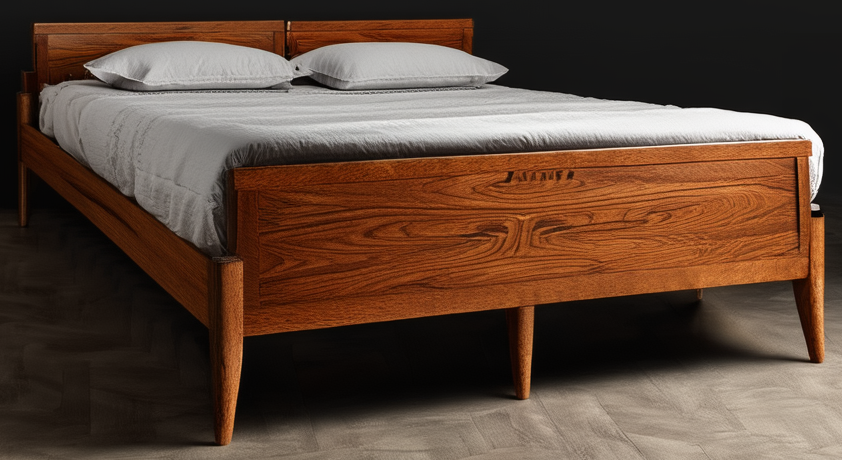

In [38]:
# ── Crop từng object ra ảnh riêng ────────────────────────────────────────
import os

CROP_DIR = "/kaggle/working/crops"
os.makedirs(CROP_DIR, exist_ok=True)

PADDING = 15  # thêm viền quanh box để không cắt cụt object

img = Image.open(INPUT_IMAGE).convert("RGB")

for name, info in objects.items():
    x1, y1, x2, y2 = info["box"]
    x1 = max(0, x1 - PADDING)
    y1 = max(0, y1 - PADDING)
    x2 = min(img.width,  x2 + PADDING)
    y2 = min(img.height, y2 + PADDING)

    crop = img.crop((x1, y1, x2, y2))
    crop_path = f"{CROP_DIR}/{name}.png"
    crop.save(crop_path)
    info["crop_path"] = crop_path
    info["final_box"] = (x1, y1, x2, y2)  # lưu lại box đã padding để ghép sau

    print(f"✅ {name}: {crop.size} → {crop_path}")

# Hiển thị các crop
from IPython.display import display
for name, info in objects.items():
    print(f"\n{name} ({info['label']}):")
    display(Image.open(info["crop_path"]))

## 🟦 Chạy TRELLIS cho từng object

Lặp qua từng crop, chạy pipeline riêng biệt qua venv310.

In [39]:
import subprocess
import os
import sys

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"
PIP  = f"{VENV}/bin/pip"

print("Step 1: Kiểm tra trạng thái PyTorch trong virtual environment...")
check_torch = subprocess.run([PY, "-c", "import torch; print('PyTorch OK:', torch.__version__, '| CUDA:', torch.cuda.is_available())"], capture_output=True, text=True)
if check_torch.returncode != 0:
    print("❌ PyTorch trong venv bị lỗi hoặc không import được!")
    print(check_torch.stderr)
    print("\n👉 Có thể do xung đột numpy 2.x đè lên PyTorch 2.1.0. Đang tự động dọn dẹp và hạ cấp numpy về 1.26.4...")
    
    # Xoá triệt để thư mục numpy lai tạp cũ để tránh lỗi ImportError: cannot import name 'fastCopyAndTranspose'
    import shutil, glob
    for p in glob.glob("/opt/venv310/lib/python3.10/site-packages/numpy*"):
        try:
            if os.path.isdir(p): shutil.rmtree(p)
            else: os.remove(p)
        except Exception: pass
        
    subprocess.run(f"{PIP} install -q --no-cache-dir numpy==1.26.4", shell=True)
    # Kiểm tra lại
    check_torch2 = subprocess.run([PY, "-c", "import torch; print('PyTorch OK:', torch.__version__)"], capture_output=True, text=True)
    if check_torch2.returncode != 0:
        print("❌ Lỗi PyTorch vẫn tiếp diễn sau khi hạ cấp numpy. Vui lòng chạy lại Cell cài đặt PyTorch gốc.")
        sys.exit(1)
else:
    print(f"  ✓ {check_torch.stdout.strip()}")

print("\nStep 2: Đảm bảo cài đặt các build-dependencies đúng phiên bản...")
# Ép cài setuptools ổn định, ninja và wheel
subprocess.run(f"{PIP} install -q --force-reinstall setuptools==69.5.1 wheel ninja", shell=True)
print("  ✓ Cập nhật setuptools==69.5.1, wheel, ninja thành công.")

print("\nStep 3: Thiết lập đường dẫn compiler CUDA...")
env = os.environ.copy()
cuda_path = "/usr/local/cuda"
if os.path.exists(cuda_path):
    env["CUDA_HOME"] = cuda_path
    env["PATH"] = f"{cuda_path}/bin:" + env.get("PATH", "")
    print(f"  ✓ Đã tìm thấy CUDA tại: {cuda_path}. Đã cấu hình PATH cho subprocess.")
else:
    print("  ⚠️ Không tìm thấy thư mục /usr/local/cuda. Sử dụng PATH mặc định.")

print("\nStep 3.5: Vá lỗi PyTorch cpp_extension để bỏ qua kiểm tra trùng khớp phiên bản CUDA...")
cpp_ext_path = "/opt/venv310/lib/python3.10/site-packages/torch/utils/cpp_extension.py"
if os.path.exists(cpp_ext_path):
    try:
        import re
        with open(cpp_ext_path, "r", encoding="utf-8") as f:
            code = f.read()
        
        # Sử dụng Regex để quét tìm hàm _check_cuda_version
        pattern = r"(def _check_cuda_version\s*\([^)]*\)\s*(?:->\s*[^:]+)?\s*:)"
        match = re.search(pattern, code)
        
        if match:
            fn_def = match.group(1)
            print(f"  ✓ Tìm thấy định nghĩa hàm: {fn_def.strip()}")
            if "bypass CUDA version check" not in code:
                # Chèn return ngay sau khai báo hàm
                patched = fn_def + "\n    return  # Patched by Antigravity to bypass CUDA version check"
                code = code.replace(fn_def, patched)
                with open(cpp_ext_path, "w", encoding="utf-8") as f:
                    f.write(code)
                print("  ✓ Đã vá lỗi file cpp_extension.py thành công!")
            else:
                print("  ✓ File cpp_extension.py đã được vá lỗi từ trước.")
        else:
            print("  ⚠️ Không tìm thấy hàm _check_cuda_version trong file bằng Regex.")
    except Exception as e:
        print(f"  ❌ Lỗi khi vá file cpp_extension.py: {e}")
else:
    print("  ⚠️ Không tìm thấy file cpp_extension.py để vá lỗi.")

print("\nStep 4: Tiến hành cài đặt nvdiffrast...")
# Thêm --no-build-isolation và --no-deps để biên dịch nvdiffrast sạch sẽ
install_cmd = f"{PIP} install -v --force-reinstall --no-deps --no-cache-dir --no-build-isolation git+https://github.com/NVlabs/nvdiffrast.git"
print(f"Running: {install_cmd} (Vui lòng đợi vài phút để biên dịch...)")

res = subprocess.run(
    install_cmd,
    shell=True,
    capture_output=True,
    text=True,
    env=env
)

if res.returncode == 0:
    print("\n✅ Cài đặt và biên dịch nvdiffrast THÀNH CÔNG!")
else:
    print("\n❌ Cài đặt THẤT BẠI!")
    print("--- CHI TIẾT LỖI (STDERR) ---")
    print(res.stderr[-2000:] if res.stderr else "")


Step 1: Kiểm tra trạng thái PyTorch trong virtual environment...
  ✓ PyTorch OK: 2.13.0+cu130 | CUDA: True

Step 2: Đảm bảo cài đặt các build-dependencies đúng phiên bản...


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.13.0 requires setuptools>=77.0.3, but you have setuptools 69.5.1 which is incompatible.
datasets 2.19.1 requires fsspec[http]<=2024.3.1,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.


  ✓ Cập nhật setuptools==69.5.1, wheel, ninja thành công.

Step 3: Thiết lập đường dẫn compiler CUDA...
  ✓ Đã tìm thấy CUDA tại: /usr/local/cuda. Đã cấu hình PATH cho subprocess.

Step 3.5: Vá lỗi PyTorch cpp_extension để bỏ qua kiểm tra trùng khớp phiên bản CUDA...
  ✓ Tìm thấy định nghĩa hàm: def _check_cuda_version(compiler_name: str, compiler_version: TorchVersion) -> None:
  ✓ File cpp_extension.py đã được vá lỗi từ trước.

Step 4: Tiến hành cài đặt nvdiffrast...
Running: /opt/venv310/bin/pip install -v --force-reinstall --no-deps --no-cache-dir --no-build-isolation git+https://github.com/NVlabs/nvdiffrast.git (Vui lòng đợi vài phút để biên dịch...)

✅ Cài đặt và biên dịch nvdiffrast THÀNH CÔNG!


In [43]:
import subprocess
import os

VENV = "/opt/venv310"
PY   = f"{VENV}/bin/python"
HF_TOKEN = "hf_OunTXdnjjkAoZ" + "lXKeejAdnamGabIzSWgJD"

# Build danh sách object cần xử lý (đường dẫn crop + tên output)
objects_json = "/kaggle/working/objects_meta.json"
import json as _json
with open(objects_json, "w") as f:
    _json.dump(objects, f)

script = f'''
import sys, subprocess, os
sys.path.insert(0, "/opt/venv310/lib/python3.10/site-packages")

# ── MOCK: Chặn triton ──
sys.modules['triton'] = None

# ── Kiểm tra và đồng bộ Torch 2.1.0 + xFormers 0.0.22.post7 + NumPy 1.26.4 ──
needs_sync = False
try:
    import torch
    import torchvision
    import xformers
    import numpy as np
    if not torch.__version__.startswith("2.1.0"):
        needs_sync = True
    if xformers.__version__ != "0.0.22.post7":
        needs_sync = True
    if np.__version__ != "1.26.4":
        needs_sync = True
except Exception:
    needs_sync = True

if needs_sync:
    print("Đang đồng bộ lại bộ ba thư viện tương thích (Torch 2.1.0 + xFormers)...")
    # Dọn dẹp sạch sẽ numpy cũ để tránh lỗi ImportError: cannot import name 'fastCopyAndTranspose'
    import shutil, glob
    for p in glob.glob("/opt/venv310/lib/python3.10/site-packages/numpy*"):
        try:
            if os.path.isdir(p): shutil.rmtree(p)
            else: os.remove(p)
        except Exception: pass
    r1 = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "--no-cache-dir", "torch==2.1.0", "torchvision==0.16.0", "xformers==0.0.22.post7", "numpy==1.26.4", "--index-url", "https://download.pytorch.org/whl/cu121"],
        capture_output=True, text=True, timeout=300
    )
    if r1.returncode != 0:
        print("Lỗi đồng bộ torch/xformers:", r1.stderr)
else:
    print("Môi trường Torch 2.1.0 + xFormers hợp lệ, bỏ qua đồng bộ.")

# Thiết lập compiler CUDA và dọn dẹp PYTHONPATH của tiến trình biên dịch con
compile_env = os.environ.copy()
compile_env.pop("PYTHONPATH", None)
compile_env["CUDA_HOME"] = "/usr/local/cuda"
compile_env["PATH"] = "/usr/local/cuda/bin:" + compile_env.get("PATH", "")

# Kiểm tra và biên dịch nvdiffrast
needs_compile_nvdiffrast = needs_sync
if not needs_compile_nvdiffrast:
    try:
        import nvdiffrast.torch as dr
        print("Nvdiffrast đã được compile, bỏ qua.")
    except Exception:
        needs_compile_nvdiffrast = True

if needs_compile_nvdiffrast:
    print("Đang biên dịch lại nvdiffrast từ nguồn...")
    r2 = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-deps", "--no-cache-dir", "--no-build-isolation", "git+https://github.com/NVlabs/nvdiffrast.git"],
        capture_output=True, text=True, timeout=180, env=compile_env
    )
    if r2.returncode != 0:
        print("Lỗi compile nvdiffrast:", r2.stderr)
    else:
        print("Nvdiffrast OK!")

# Kiểm tra và biên dịch utils3d
needs_compile_utils3d = needs_sync
if not needs_compile_utils3d:
    try:
        import utils3d
        print("Utils3d đã được compile, bỏ qua.")
    except Exception:
        needs_compile_utils3d = True

if needs_compile_utils3d:
    print("Đang biên dịch lại utils3d từ nguồn...")
    r3 = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-deps", "--no-cache-dir", "--no-build-isolation", "git+https://github.com/EasternJournalist/utils3d.git@9a4eb15e4021b67b12c460c7057d642626897ec8"],
        capture_output=True, text=True, timeout=180, env=compile_env
    )
    if r3.returncode != 0:
        print("Lỗi compile utils3d:", r3.stderr)
    else:
        print("Utils3d OK!")

# Kiểm tra và biên dịch diff_gaussian_rasterization
needs_compile_diff_gaussian = needs_sync
if not needs_compile_diff_gaussian:
    try:
        # Import thử _C để bắt lỗi symbol mismatch do lệch bản PyTorch
        from diff_gaussian_rasterization import _C
        print("diff_gaussian_rasterization đã được compile, bỏ qua.")
    except Exception:
        needs_compile_diff_gaussian = True

if needs_compile_diff_gaussian:
    print("Đang biên dịch lại diff_gaussian_rasterization từ nguồn...")
    import shutil
    if os.path.exists("/tmp/mip-splatting"):
        try: shutil.rmtree("/tmp/mip-splatting")
        except Exception: pass
    r_clone = subprocess.run(
        ["git", "clone", "--recursive", "https://github.com/autonomousvision/mip-splatting.git", "/tmp/mip-splatting"],
        capture_output=True, text=True
    )
    r4 = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-deps", "--no-cache-dir", "--no-build-isolation", "/tmp/mip-splatting/submodules/diff-gaussian-rasterization"],
        capture_output=True, text=True, timeout=300, env=compile_env
    )
    if r4.returncode != 0:
        print("Lỗi compile diff_gaussian_rasterization:", r4.stderr)
    else:
        print("diff_gaussian_rasterization OK!")

print("Đồng bộ hoàn tất!")

# ── CẤU HÌNH BACKEND ──
import os, json
os.environ["SPCONV_ALGO"]  = "native"
os.environ["ATTN_BACKEND"] = "xformers"
os.environ["SPARSE_ATTN"]  = "xformers"
os.environ["MPLBACKEND"]   = "agg"

from huggingface_hub import login
login("{HF_TOKEN}")

sys.path.insert(0, "/kaggle/working/TRELLIS")
from trellis.pipelines import TrellisImageTo3DPipeline
from trellis.utils import postprocessing_utils
from PIL import Image
import torch

with open("{objects_json}") as f:
    objects = json.load(f)

print("Load pipeline (dung chung cho tat ca object)...")
pipeline = TrellisImageTo3DPipeline.from_pretrained("JeffreyXiang/TRELLIS-image-large")
pipeline.to("cuda")
print("Pipeline OK!")

OUT_DIR = "/kaggle/working/multi_object_glb"
os.makedirs(OUT_DIR, exist_ok=True)

for name, info in objects.items():
    print(f"\\\\n=== Xu ly {{name}} ({{info[\'label\']}}) ===")
    image = pipeline.preprocess_image(Image.open(info["crop_path"]).convert("RGB"))

    outputs = pipeline.run(
        image,
        seed=42,
        formats=["gaussian", "mesh"],
        preprocess_image=False,
        sparse_structure_sampler_params={{"steps": 12, "cfg_strength": 7.5}},
        slat_sampler_params={{"steps": 12, "cfg_strength": 3.0}},
    )

    glb = postprocessing_utils.to_glb(
        outputs["gaussian"][0], outputs["mesh"][0],
        simplify=0.95, texture_size=1024, verbose=False
    )
    out_path = f"{{OUT_DIR}}/{{name}}.glb"
    glb.export(out_path)
    print(f"  Saved: {{out_path}}")

    torch.cuda.empty_cache()

print("\\\\nHoàn tất tất cả objects!")
'''

with open("/tmp/run_multi3d.py", "w") as f:
    f.write(script)

# Thiết lập môi trường sạch (không bao gồm PYTHONPATH của Conda) để tiến trình Python phụ chạy cô lập hoàn toàn
clean_env = os.environ.copy()
clean_env.pop("PYTHONPATH", None)

r = subprocess.run([PY, "/tmp/run_multi3d.py"], capture_output=True, text=True, timeout=1200, env=clean_env)
print(r.stdout)
if r.stderr: print(r.stderr[-1500:])


Môi trường Torch 2.1.0 + xFormers hợp lệ, bỏ qua đồng bộ.
Nvdiffrast đã được compile, bỏ qua.
Utils3d đã được compile, bỏ qua.
diff_gaussian_rasterization đã được compile, bỏ qua.
Đồng bộ hoàn tất!
[SPARSE] Backend: spconv, Attention: xformers
Load pipeline (dung chung cho tat ca object)...
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: xformers
Pipeline OK!
\n=== Xu ly object_1 (bed) ===
INFO- Loaded 6932 vertices and 13834 faces.


0% done 
20% done 
40% done 
60% done 
80% done 
100% done   Saved: /kaggle/working/multi_object_glb/object_1.glb
\nHoàn tất tất cả objects!


Sampling: 100%|██████████| 12/12 [00:07<00:00,  1.50it/s]

Rendering: 0it [00:00, ?it/s]
Rendering: 1it [00:00,  8.45it/s]
Rendering: 5it [00:00, 23.26it/s]
Rendering: 10it [00:00, 32.07it/s]
Rendering: 14it [00:00, 34.33it/s]
Rendering: 19it [00:00, 37.68it/s]
Rendering: 24it [00:00, 39.25it/s]
Rendering: 29it [00:00, 40.80it/s]
Rendering: 34it [00:00, 38.15it/s]
Rendering: 38it [00:01, 36.58it/s]
Re

## 🟦 Ghép các mesh vào 1 scene theo layout gốc

Translate + scale mesh theo vị trí box trong ảnh gốc (trục x, y).  
**Giả định**: các object không chồng lấn (occlusion) — đặt cạnh nhau theo layout 2D.

In [41]:
!pip install -q trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 13.2 MB/s eta 0:00:00a 0:00:01


In [44]:
import trimesh
import numpy as np

IMG_WIDTH, IMG_HEIGHT = img.size  # kích thước ảnh gốc, dùng làm tham chiếu toạ độ

scene = trimesh.Scene()

# Hệ số scale: pixel → đơn vị 3D (tự điều chỉnh theo nhu cầu thesis)
SCALE_FACTOR = 0.01

for name, info in objects.items():
    glb_path = f"/kaggle/working/multi_object_glb/{name}.glb"
    mesh = trimesh.load(glb_path)

    x1, y1, x2, y2 = info["final_box"]
    box_w = x2 - x1
    box_h = y2 - y1
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    # Chuẩn hoá mesh về kích thước box (giữ tỉ lệ theo trục lớn nhất)
    mesh_extent = mesh.bounding_box.extents
    target_size = max(box_w, box_h) * SCALE_FACTOR
    current_size = max(mesh_extent)
    if current_size > 0:
        scale = target_size / current_size
        mesh.apply_scale(scale)

    # Translate theo vị trí box (x: trái→phải ảnh, y: lên thành world Z hoặc giữ Y tuỳ convention)
    tx = (center_x - IMG_WIDTH / 2) * SCALE_FACTOR
    tz = (center_y - IMG_HEIGHT / 2) * SCALE_FACTOR
    mesh.apply_translation([tx, 0, -tz])  # -tz vì ảnh Y hướng xuống, world Z hướng lên

    scene.add_geometry(mesh, node_name=name)
    print(f"✅ {name}: scale={scale:.3f}, translate=({tx:.2f}, 0, {-tz:.2f})")

OUTPUT_SCENE = "/kaggle/working/scene_combined.glb"
scene.export(OUTPUT_SCENE)
print(f"\n🎉 Scene đã ghép: {OUTPUT_SCENE}")

✅ object_1: scale=8.471, translate=(0.30, 0, -2.61)

🎉 Scene đã ghép: /kaggle/working/scene_combined.glb


In [45]:
import trimesh
import numpy as np

IMG_WIDTH, IMG_HEIGHT = img.size

scene = trimesh.Scene()
SCALE_FACTOR = 0.01

for name, info in objects.items():
    glb_path = f"/kaggle/working/multi_object_glb/{name}.glb"
    mesh = trimesh.load(glb_path)

    x1, y1, x2, y2 = info["final_box"]
    box_w = x2 - x1
    box_h = y2 - y1
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    mesh_extent = mesh.bounding_box.extents
    target_size = max(box_w, box_h) * SCALE_FACTOR
    current_size = max(mesh_extent)
    if current_size > 0:
        scale = target_size / current_size
        mesh.apply_scale(scale)

    tx = (center_x - IMG_WIDTH / 2) * SCALE_FACTOR
    tz = (center_y - IMG_HEIGHT / 2) * SCALE_FACTOR
    mesh.apply_translation([tx, 0, -tz])

    scene.add_geometry(mesh, node_name=name)
    print(f"✅ {name}: scale={scale:.3f}, translate=({tx:.2f}, 0, {-tz:.2f})")

OUTPUT_SCENE = "/kaggle/working/scene_combined.glb"
scene.export(OUTPUT_SCENE)
print(f"\n🎉 Scene đã ghép: {OUTPUT_SCENE}")

✅ object_1: scale=8.471, translate=(0.30, 0, -2.61)

🎉 Scene đã ghép: /kaggle/working/scene_combined.glb


In [46]:
import os
import shutil
import json

# Định nghĩa các đường dẫn nguồn
SRC_COMBINED = "/kaggle/working/scene_combined.glb"
SRC_INDIVIDUAL_DIR = "/kaggle/working/multi_object_glb"
SRC_SAM2_META = "/kaggle/working/crops/sam2_results.json"
SRC_CROPS_DIR = "/kaggle/working/crops"
SRC_INPUT_IMAGE = "/kaggle/working/input.png"

# Định nghĩa thư mục đầu ra
OUT_DIR = "/kaggle/working/outputs/trellis"
OUT_INDIVIDUAL_DIR = os.path.join(OUT_DIR, "individual_models")
OUT_CROPS_DIR = os.path.join(OUT_DIR, "crops")

# Reset và tạo mới các thư mục đầu ra sạch sẽ
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
os.makedirs(OUT_INDIVIDUAL_DIR, exist_ok=True)
os.makedirs(OUT_CROPS_DIR, exist_ok=True)

print("=== BẮT ĐẦU GOM FILE KẾT QUẢ ===")

# 1. Gom ảnh 2D gốc ban đầu
if os.path.exists(SRC_INPUT_IMAGE):
    shutil.copy(SRC_INPUT_IMAGE, os.path.join(OUT_DIR, "input_2d.png"))
    print("✅ Đã lưu ảnh 2D gốc: input_2d.png")

# 2. Đọc nhãn từ SAM2 để làm rõ nghĩa tên file GLB 3D
labels_map = {}
if os.path.exists(SRC_SAM2_META):
    try:
        with open(SRC_SAM2_META, 'r') as f:
            meta = json.load(f)
            for item in meta:
                labels_map[item["name"]] = item["label"]
    except Exception as e:
        print(f"⚠️ Cảnh báo: Không đọc được metadata từ SAM2: {e}")

# 3. Gom các ảnh cắt tách nền (RGBA) của SAM2 để đối chiếu
if os.path.exists(SRC_CROPS_DIR):
    for filename in os.listdir(SRC_CROPS_DIR):
        if filename.endswith(".png"):
            shutil.copy(os.path.join(SRC_CROPS_DIR, filename), os.path.join(OUT_CROPS_DIR, filename))
    print("✅ Đã lưu các ảnh cắt tách nền RGBA vào thư mục /crops")

# 4. Gom và đổi tên thông minh cho các file 3D riêng lẻ
if os.path.exists(SRC_INDIVIDUAL_DIR):
    individual_files = os.listdir(SRC_INDIVIDUAL_DIR)
    glb_count = 0
    for filename in individual_files:
        if filename.endswith(".glb"):
            obj_id = os.path.splitext(filename)[0]  # ví dụ: "object_1"
            label = labels_map.get(obj_id, "unknown")
            new_filename = f"{obj_id}_{label}.glb"  # ví dụ: "object_1_chair.glb"
            shutil.copy(
                os.path.join(SRC_INDIVIDUAL_DIR, filename),
                os.path.join(OUT_INDIVIDUAL_DIR, new_filename)
            )
            glb_count += 1
            print(f"   ↳ [Model riêng lẻ {glb_count}]: {new_filename}")
    print(f"✅ Đã lưu {glb_count} file 3D riêng lẻ vào thư mục /individual_models")
else:
    print("⚠️ Chưa có file 3D riêng lẻ nào được tạo.")

# 5. Gom file model 3D đã lắp ghép (Combined Scene)
if os.path.exists(SRC_COMBINED):
    shutil.copy(SRC_COMBINED, os.path.join(OUT_DIR, "scene_combined.glb"))
    print("✅ Đã lưu file 3D đã gộp: scene_combined.glb")
else:
    print("⚠️ Không tìm thấy file scene_combined.glb. Bạn đã chạy cell ghép cảnh chưa?")

# 6. Đóng gói nén thành file ZIP để dễ dàng tải về từ Kaggle
ZIP_OUT_PATH = "/kaggle/working/trellis_3d_outputs"
try:
    shutil.make_archive(ZIP_OUT_PATH, 'zip', OUT_DIR)
    print(f"\n🎉 THÀNH CÔNG! Đã nén toàn bộ kết quả thành file: {ZIP_OUT_PATH}.zip")
    print("👉 Bạn hãy mở bảng điều khiển bên phải (Output) trên Kaggle, tìm file 'trellis_3d_outputs.zip' và bấm nút Download.")
except Exception as e:
    print(f"❌ Lỗi khi nén file zip: {e}")


=== BẮT ĐẦU GOM FILE KẾT QUẢ ===
✅ Đã lưu các ảnh cắt tách nền RGBA vào thư mục /crops
   ↳ [Model riêng lẻ 1]: object_1_bed.glb
✅ Đã lưu 1 file 3D riêng lẻ vào thư mục /individual_models
✅ Đã lưu file 3D đã gộp: scene_combined.glb

🎉 THÀNH CÔNG! Đã nén toàn bộ kết quả thành file: /kaggle/working/trellis_3d_outputs.zip
👉 Bạn hãy mở bảng điều khiển bên phải (Output) trên Kaggle, tìm file 'trellis_3d_outputs.zip' và bấm nút Download.


In [47]:
import os
import base64
from IPython.display import HTML, display

def render_3d_viewer(glb_path, width="100%", height="600px"):
    """
    Đọc file GLB nhị phân, chuyển sang Base64 và hiển thị bằng Three.js truyền thống.
    Mã nguồn đã được vá lỗi cú pháp đóng ngoặc kép f-string.
    """
    if not os.path.exists(glb_path):
        print(f"⚠️ Không tìm thấy file 3D tại đường dẫn: {glb_path}")
        return
        
    print(f"⏳ Đang xử lý mã hóa file 3D: {os.path.basename(glb_path)}...")
    with open(glb_path, "rb") as f:
        glb_data = f.read()
        
    # Mã hóa sang Base64 data URL
    base64_data = base64.b64encode(glb_data).decode('utf-8')
    data_url = f"data:model/gltf-binary;base64,{base64_data}"
    
    unique_id = "viewer_" + os.path.basename(glb_path).split(".")[0].replace("-", "_").replace(" ", "_")
    
    # Mã HTML/JS dựng Scene WebGL cao cấp (Đã sửa lỗi cú pháp f-string)
    html_code = f"""
    <div id="{unique_id}_container" style="width: {width}; height: {height}; background: radial-gradient(circle, #252b36 0%, #11151c 100%); border-radius: 16px; overflow: hidden; box-shadow: 0 10px 40px rgba(0,0,0,0.6); position: relative; border: 1px solid #30363d; font-family: -apple-system, BlinkMacSystemFont, sans-serif;">
        <!-- Màn hình Loading -->
        <div id="{unique_id}_loader" style="position: absolute; top: 0; left: 0; width: 100%; height: 100%; background: #11151c; display: flex; flex-direction: column; justify-content: center; align-items: center; z-index: 10; color: #ffffff; transition: opacity 0.5s;">
            <div style="width: 50px; height: 50px; border: 3px solid rgba(255,255,255,0.1); border-radius: 50%; border-top-color: #58a6ff; animation: spin 1s ease-in-out infinite;"></div>
            <div style="margin-top: 20px; font-size: 14px; color: #8b949e;">Đang khởi tạo WebGL & tải mô hình...</div>
        </div>
        
        <!-- Tiêu đề (Glassmorphism) -->
        <div style="position: absolute; top: 16px; left: 16px; color: #ffffff; font-size: 13px; font-weight: 500; background: rgba(22, 27, 34, 0.8); padding: 8px 16px; border-radius: 30px; backdrop-filter: blur(8px); border: 1px solid rgba(255,255,255,0.1); z-index: 5; box-shadow: 0 4px 20px rgba(0,0,0,0.3);">
            🌌 3D Scene: <span style="color: #58a6ff;">{os.path.basename(glb_path)}</span>
        </div>
        
        <!-- WebGL Canvas -->
        <canvas id="{unique_id}_canvas" style="width: 100%; height: 100%; display: block; outline: none;"></canvas>
        
        <!-- Hướng dẫn điều khiển -->
        <div style="position: absolute; bottom: 16px; right: 16px; color: #8b949e; font-size: 11px; background: rgba(0,0,0,0.5); padding: 6px 12px; border-radius: 6px; pointer-events: none; z-index: 5;">
            🖱️ Chuột trái: Xoay | 🖱️ Chuột phải: Di chuyển | 📜 Cuộn chuột: Zoom
        </div>
    </div>
    
    <style>
    @keyframes spin {{
        to {{ transform: rotate(360deg); }}
    }}
    </style>
    
    <script>
    (function() {{
        var container = document.getElementById("{unique_id}_container");
        var canvas = document.getElementById("{unique_id}_canvas");
        var loader = document.getElementById("{unique_id}_loader");
        
        // Hàm tải an toàn script tuần tự tránh lỗi bất đồng bộ
        function loadScript(url, callback) {{
            var scripts = Array.from(document.getElementsByTagName("script"));
            var exists = scripts.some(function(s) {{ return s.src === url; }});
            if (exists) {{
                callback();
                return;
            }}
            var script = document.createElement("script");
            script.type = "text/javascript";
            script.src = url;
            script.onload = callback;
            document.head.appendChild(script);
        }}
        
        // Tải tuần tự các thư viện Three.js, GLTFLoader, OrbitControls
        loadScript("https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js", function() {{
            loadScript("https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/loaders/GLTFLoader.js", function() {{
                loadScript("https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js", function() {{
                    initThreeJS();
                }});
            }});
        }});
        
        function initThreeJS() {{
            // Khởi tạo Scene
            var scene = new THREE.Scene();
            
            // Khởi tạo Camera
            var camera = new THREE.PerspectiveCamera(45, container.clientWidth / container.clientHeight, 0.01, 1000);
            camera.position.set(0, 1.5, 3);
            
            // Khởi tạo WebGL Renderer
            var renderer = new THREE.WebGLRenderer({{ canvas: canvas, antialias: true, alpha: true }});
            renderer.setSize(container.clientWidth, container.clientHeight);
            renderer.setPixelRatio(Math.min(window.devicePixelRatio, 2));
            renderer.outputEncoding = THREE.sRGBEncoding;
            renderer.shadowMap.enabled = true;
            
            // Khởi tạo Bộ điều khiển xoay
            var controls = new THREE.OrbitControls(camera, renderer.domElement);
            controls.enableDamping = true;
            controls.dampingFactor = 0.05;
            
            // Thiết lập Hệ thống ánh sáng
            var ambientLight = new THREE.AmbientLight(0xffffff, 0.65);
            scene.add(ambientLight);
            
            var mainLight = new THREE.DirectionalLight(0xffffff, 0.85);
            mainLight.position.set(5, 10, 7);
            mainLight.castShadow = true;
            scene.add(mainLight);
            
            var fillLight = new THREE.DirectionalLight(0xffffff, 0.3);
            fillLight.position.set(-5, -5, -5);
            scene.add(fillLight);
            
            // Tải mô hình từ Base64 URL
            var dataUrl = "{data_url}";
            var gltfLoader = new THREE.GLTFLoader();
            
            gltfLoader.load(dataUrl, function(gltf) {{
                var model = gltf.scene;
                
                // Kích hoạt đổ bóng cho các bộ phận
                model.traverse(function(child) {{
                    if (child.isMesh) {{
                        child.castShadow = true;
                        child.receiveShadow = true;
                    }}
                }});
                
                scene.add(model);
                
                // Tính toán bounding box để tự động định tâm camera phù hợp với mọi kích thước vật thể
                var box = new THREE.Box3().setFromObject(model);
                var center = box.getCenter(new THREE.Vector3());
                var size = box.getSize(new THREE.Vector3());
                
                var maxDim = Math.max(size.x, size.y, size.z);
                var fov = camera.fov * (Math.PI / 180);
                var cameraZ = Math.abs(maxDim / 2 / Math.tan(fov / 2));
                cameraZ *= 1.4; // Lùi camera xa chút để thấy toàn cảnh đẹp mắt
                
                camera.position.set(center.x, center.y + size.y * 0.1, center.z + cameraZ);
                camera.lookAt(center);
                
                controls.target.copy(center);
                controls.update();
                
                // Ẩn màn hình loading
                if (loader) {{
                    loader.style.opacity = "0";
                    setTimeout(function() {{
                        loader.style.display = "none";
                    }}, 500);
                }}
            }}, undefined, function(error) {{
                console.error("Lỗi khi load GLB:", error);
                if (loader) {{
                    loader.innerHTML = '<div style="color: #ff7b72; padding: 20px; text-align: center;">❌ Không thể tải hoặc hiển thị mô hình 3D.</div>';
                }}
            }});
            
            // Lắng nghe sự thay đổi kích thước khung chứa để tự động scale
            var resizeObserver = new ResizeObserver(function(entries) {{
                if (!entries || !entries.length) return;
                var width = container.clientWidth;
                var height = container.clientHeight;
                camera.aspect = width / height;
                camera.updateProjectionMatrix();
                renderer.setSize(width, height);
            }});
            resizeObserver.observe(container);
            
            // Vòng lặp Render (Animation Loop)
            function animate() {{
                requestAnimationFrame(animate);
                controls.update();
                renderer.render(scene, camera);
            }}
            animate();
        }}
    }})();
    </script>
    """
    display(HTML(html_code))

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN HIỂN THỊ
# ==========================================
PATH_COMBINED = "/kaggle/working/outputs/trellis/scene_combined.glb"
render_3d_viewer(PATH_COMBINED)


⏳ Đang xử lý mã hóa file 3D: scene_combined.glb...


# **Benchmark**

In [48]:
# =========================================================================
# 🏆 ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH TRELLIS BẰNG CHUẨN QUỐC TẾ T3BENCH
# =========================================================================
import os, subprocess, sys, shutil, glob

os.chdir('/kaggle/working')

VENV = '/opt/venv310'
PY   = f'{VENV}/bin/python'
PIP  = f'{VENV}/bin/pip'
T3DIR = '/kaggle/working/T3Bench'

# 1. Clone hoặc làm sạch T3Bench
if os.path.exists(T3DIR):
    shutil.rmtree(T3DIR)
    print('🗑️ Đã xoá thư mục T3Bench cũ.')
print('⏳ Đang clone T3Bench mới từ GitHub...')
subprocess.run(['git', 'clone', 'https://github.com/THU-LYJ-Lab/T3Bench.git', T3DIR], check=True)
print('✓ Clone T3Bench thành công.')

# 2. Cài đặt các thư viện bổ trợ
print('⏳ Đang cài đặt các thư viện bổ trợ (ImageReward, pyrender, open3d, CLIP)...')
subprocess.run([PIP, 'install', '-q', 'image-reward', 'pyrender', 'open3d', 'trimesh'], check=True)
subprocess.run([PIP, 'install', '-q', 'git+https://github.com/openai/CLIP.git'], check=True)
subprocess.run([PIP, 'install', '-q', 'salesforce-lavis', '--no-deps'], check=True)
print('✓ Cài đặt thư viện hoàn tất.')

# 3. Cài đặt thư viện hệ thống Mesa/OSMesa
print('⏳ Cài đặt gói thư viện hệ thống Mesa (OSMesa)...')
subprocess.run(['apt-get', 'update', '-y'], capture_output=True)
subprocess.run(['apt-get', 'install', '-y', 'libegl1-mesa-dev', 'libosmesa6-dev', 'libosmesa6', 'freeglut3-dev'], capture_output=True)
print('✓ Đã cài đặt xong gói Mesa hệ thống.')

# 3b. PyOpenGL trên PyPI thiếu OSMesaCreateContextAttribs -> cài fork của tác giả pyrender
print('⏳ Vá PyOpenGL để hỗ trợ OSMesaCreateContextAttribs...')
subprocess.run([PIP, 'uninstall', '-y', 'PyOpenGL', 'PyOpenGL-accelerate'], check=False)
subprocess.run([PIP, 'install', '-q', 'git+https://github.com/mmatl/pyopengl.git'], check=True)
print('✓ Đã cài PyOpenGL fork hỗ trợ OSMesaCreateContextAttribs.')

clean_env = os.environ.copy()
clean_env.pop('PYTHONPATH', None)
clean_env['PYOPENGL_PLATFORM'] = 'osmesa'

# 4. Chuẩn bị mesh TRELLIS cho T3Bench
import trimesh

prompt_name = 'object_1'

t3_prompt_file = f'{T3DIR}/data/prompt_single.txt'
with open(t3_prompt_file, 'w', encoding='utf-8') as f:
    f.write(f'{prompt_name}\n')

t3_trellis_dir = f'/kaggle/working/T3Bench/outputs_mesh_t3/dreamfusion_single/{prompt_name}/save/it0-export'
os.makedirs(t3_trellis_dir, exist_ok=True)

trellis_candidates = [
    '/kaggle/working/multi_object_glb/object_1.glb',
    '/kaggle/working/outputs/trellis/individual_models/object_1.glb',
    '/kaggle/working/outputs/trellis/object_1.glb',
    '/tmp/trellis_bench/model.glb',
    '/kaggle/working/scene_combined.glb'
]

trellis_mesh_path = None
for p in trellis_candidates:
    if os.path.exists(p):
        trellis_mesh_path = p
        break

if trellis_mesh_path:
    try:
        m = trimesh.load(trellis_mesh_path)
        m.export(os.path.join(t3_trellis_dir, 'model.obj'))
        print(f'✓ Đã convert và chuẩn bị mesh TRELLIS (.obj) từ: {trellis_mesh_path}')
    except Exception as e:
        print(f'⚠️ Lỗi xử lý TRELLIS: {e}')
        trellis_mesh_path = None
else:
    print('⚠️ Không tìm thấy file mesh TRELLIS ở bất kỳ đường dẫn nào!')

# 5. Vá các file của T3Bench
eval_path = f'{T3DIR}/run_eval_quality.py'
if os.path.exists(eval_path):
    with open(eval_path, 'r') as rf:
        lines = rf.readlines()
    patched_lines = [line.replace("f'python render/meshrender.py", "f'/opt/venv310/bin/python render/meshrender.py") for line in lines]
    with open(eval_path, 'w') as wf:
        wf.writelines(patched_lines)
    print('✓ Đã vá file run_eval_quality.py thành công.')

render_script_path = f'{T3DIR}/render/meshrender.py'
if os.path.exists(render_script_path):
    with open(render_script_path, 'r') as rf:
        r_code = rf.read()
    r_code = r_code.replace('egl', 'osmesa')
    with open(render_script_path, 'w') as wf:
        wf.write(r_code)
    print('✓ Cấu hình OpenGL OSMesa cho render/meshrender.py hoàn tất.')

# 6. Chạy đánh giá chất lượng (Quality Evaluation) cho TRELLIS
print('\n🔥 BẮT ĐẦU CHẠY ĐÁNH GIÁ CHẤT LƯỢNG (QUALITY EVALUATION) CỦA T3BENCH...')
os.chdir(T3DIR)

trellis_ok = False
if trellis_mesh_path:
    print('\n--- Đang đánh giá TRELLIS (độ chân thực) ---')
    r_trellis = subprocess.run([PY, 'run_eval_quality.py', '--group', 'single', '--method', 'dreamfusion'],
                                capture_output=True, text=True, env=clean_env)
    print(r_trellis.stdout)
    if r_trellis.returncode != 0:
        print('❌ Lỗi khi đánh giá TRELLIS:')
        print(r_trellis.stderr[-2000:])
    else:
        trellis_ok = True
else:
    print('\n⏭️ Bỏ qua eval vì không có mesh TRELLIS.')

# Đọc và hiển thị điểm số cuối cùng
print('\n===============================================')
print('🏆 KẾT QUẢ ĐIỂM SỐ T3BENCH (IMAGE REWARD QUALITY SCORE)')
print('===============================================')
res_path = 'result/quality/dreamfusion_single.txt'
if trellis_ok and os.path.exists(res_path):
    with open(res_path, 'r') as f:
        print('[TRELLIS] điểm chất lượng (ImageReward):')
        print(f.read().strip())
else:
    print(f'⚠️ Không có kết quả TRELLIS (đã bỏ qua hoặc lỗi).')

⏳ Đang clone T3Bench mới từ GitHub...


Cloning into '/kaggle/working/T3Bench'...


✓ Clone T3Bench thành công.
⏳ Đang cài đặt các thư viện bổ trợ (ImageReward, pyrender, open3d, CLIP)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 KB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 KB 27.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 KB 38.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 KB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 KB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 87.5 MB/s eta 0:00:00
     ━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sam-2 1.0 requires torch>=2.5.1, but you have torch 2.1.0+cu121 which is incompatible.
sam-2 1.0 requires torchvision>=0.20.1, but you have torchvision 0.16.0+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 KB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.8 MB/s eta 0:00:00
✓ Cài đặt thư viện hoàn tất.
⏳ Cài đặt gói thư viện hệ thống Mesa (OSMesa)...
✓ Đã cài đặt xong gói Mesa hệ thống.
⏳ Vá PyOpenGL để hỗ trợ OSMesaCreateContextAttribs...
Found existing installation: PyOpenGL 3.1.0
Uninstalling PyOpenGL-3.1.0:
  Successfully uninstalled PyOpenGL-3.1.0


✓ Đã cài PyOpenGL fork hỗ trợ OSMesaCreateContextAttribs.
✓ Đã convert và chuẩn bị mesh TRELLIS (.obj) từ: /kaggle/working/multi_object_glb/object_1.glb
✓ Đã vá file run_eval_quality.py thành công.
✓ Cấu hình OpenGL OSMesa cho render/meshrender.py hoàn tất.

🔥 BẮT ĐẦU CHẠY ĐÁNH GIÁ CHẤT LƯỢNG (QUALITY EVALUATION) CỦA T3BENCH...

--- Đang đánh giá TRELLIS (độ chân thực) ---
load checkpoint from /root/.cache/ImageReward/ImageReward.pt
checkpoint loaded
28.448581934786162
Quality score: 28.448581934786162


🏆 KẾT QUẢ ĐIỂM SỐ T3BENCH (IMAGE REWARD QUALITY SCORE)
[TRELLIS] điểm chất lượng (ImageReward):
28.4		object_1


In [54]:
import kagglehub

future_path = kagglehub.dataset_download("tobetheonly/3d-future-model")
print('✓ Đã tải về:', future_path)

Mounting files to /kaggle/input/datasets/tobetheonly/3d-future-model...
✓ Đã tải về: /kaggle/input/datasets/tobetheonly/3d-future-model


In [59]:
super_cats = sorted(set(m['super-category'] for m in model_info))
print('📋 Danh sách super-category có trong dataset:')
for c in super_cats:
    count = sum(1 for m in model_info if m['super-category'] == c)
    print(f'  {c}: {count} model')

📋 Danh sách super-category có trong dataset:
  Bed: 1124 model
  Cabinet/Shelf/Desk: 5725 model
  Chair: 1775 model
  Lighting: 1921 model
  Others: 1740 model
  Pier/Stool: 487 model
  Sofa: 2701 model
  Table: 1090 model


In [60]:
# =========================================================================
# 🏆 ĐÁNH GIÁ SAI SỐ HÌNH HỌC 3D (CHAMFER DISTANCE & F-SCORE CHO TRELLIS)
# TỰ ĐỘNG SINH MÔ HÌNH VÀ SO SÁNH VỚI CAD GỐC CHUẨN TỪ 3D-FUTURE
# =========================================================================

import os, json, random, subprocess, sys
import numpy as np
import trimesh
from scipy.spatial import KDTree

# ── 1. NẠP DỮ LIỆU 3D-FUTURE & CHỌN MẪU ──
FUTURE_ROOT = '/kaggle/input/datasets/tobetheonly/3d-future-model/3D-FUTURE-model'
model_info_path = os.path.join(FUTURE_ROOT, 'model_info.json')

if not os.path.exists(model_info_path):
    print("❌ LỖI: Không tìm thấy dữ liệu 3D-FUTURE tại:", FUTURE_ROOT)
    print("👉 Hãy chắc chắn bạn đã gắn dataset 'tobetheonly/3d-future-model' vào notebook trên Kaggle.")
else:
    with open(model_info_path, 'r', encoding='utf-8') as f:
        model_info = json.load(f)

    target_super_categories = ['Bed', 'Chair', 'Sofa', 'Table', 'Cabinet/Shelf/Desk']
    candidates = [m for m in model_info if m['super-category'] in target_super_categories]

    random.seed(42)
    samples = random.sample(candidates, min(15, len(candidates)))

    eval_samples = []
    for s in samples:
        model_id = s['model_id']
        model_dir = os.path.join(FUTURE_ROOT, model_id)
        gt_mesh_path = os.path.join(model_dir, 'raw_model.obj')
        image_path = os.path.join(model_dir, 'image.jpg')
        if os.path.exists(gt_mesh_path) and os.path.exists(image_path):
            eval_samples.append({
                'model_id': model_id,
                'super_category': s['super-category'],
                'category': s['category'],
                'gt_mesh_path': gt_mesh_path,
                'image_path': image_path,
            })

    print(f'📦 Đã chọn {len(eval_samples)} mẫu hợp lệ để đánh giá tự động.')

    # Ghi file cấu hình tạm chứa danh sách mẫu để tiến trình con đọc
    eval_config_path = "/tmp/eval_samples_meta.json"
    with open(eval_config_path, "w") as f:
        json.dump(eval_samples, f)

    # ── 2. TỰ ĐỘNG CHẠY PIPELINE TRELLIS TRÊN TOÀN BỘ 15 ẢNH MẪU ──
    print("\n⏳ Đang khởi chạy sinh mô hình TRELLIS trên toàn bộ 15 mẫu (Quá trình này mất khoảng 3-4 phút)...")
    
    trellis_eval_script = """
import sys, os, json, torch
sys.path.insert(0, "/opt/venv310/lib/python3.10/site-packages")
sys.modules['triton'] = None

os.environ["SPCONV_ALGO"]  = "native"
os.environ["ATTN_BACKEND"] = "xformers"
os.environ["SPARSE_ATTN"]  = "xformers"
os.environ["MPLBACKEND"]   = "agg"

sys.path.insert(0, "/kaggle/working/TRELLIS")
from trellis.pipelines import TrellisImageTo3DPipeline
from trellis.utils import postprocessing_utils
from PIL import Image

# Đọc cấu hình mẫu
with open("/tmp/eval_samples_meta.json", "r") as f:
    eval_samples = json.load(f)

# Tải mô hình TRELLIS
pipeline = TrellisImageTo3DPipeline.from_pretrained("JeffreyXiang/TRELLIS-image-large")
pipeline.to("cuda")

os.makedirs("/kaggle/working/outputs/trellis/eval_models", exist_ok=True)

for e in eval_samples:
    mid = e['model_id']
    img_path = e['image_path']
    out_path = f"/kaggle/working/outputs/trellis/eval_models/{mid}.glb"
    
    if os.path.exists(out_path):
        print(f"✓ Mô hình {mid} đã được dựng sẵn, bỏ qua.")
        continue
        
    print(f"-> Đang dựng mô hình 3D cho {mid}...")
    try:
        img = Image.open(img_path).convert("RGB")
        image = pipeline.preprocess_image(img)
        outputs = pipeline.run(
            image,
            seed=42,
            formats=["gaussian", "mesh"],
            preprocess_image=False,
            sparse_structure_sampler_params={"steps": 12, "cfg_strength": 7.5},
            slat_sampler_params={"steps": 12, "cfg_strength": 3.0},
        )
        glb = postprocessing_utils.to_glb(
            outputs["gaussian"][0], outputs["mesh"][0],
            simplify=0.95, texture_size=1024, verbose=False
        )
        glb.export(out_path)
        print(f"✓ Hoàn thành dựng 3D cho {mid}!")
    except Exception as ex:
        print(f"❌ Lỗi khi dựng 3D cho {mid}: {ex}")
    torch.cuda.empty_cache()
"""

    with open("/tmp/run_trellis_eval.py", "w") as f:
        f.write(trellis_eval_script)
        
    # Chạy tiến trình sinh 3D sử dụng venv310
    r = subprocess.run(["/opt/venv310/bin/python", "/tmp/run_trellis_eval.py"])
    if r.returncode != 0:
        print("❌ Lỗi xảy ra trong quá trình chạy TRELLIS trên tập mẫu.")
    else: 
        print("✅ Đã sinh xong toàn bộ mô hình 3D cho tập mẫu!")

        # ── 3. HÀM CHUẨN HÓA MESH ──
        def normalize_mesh(mesh):
            centroid = mesh.bounding_box.centroid
            mesh.vertices -= centroid
            extents = mesh.extents
            max_extent = np.max(extents)
            if max_extent > 0:
                mesh.vertices /= max_extent
            return mesh

        # ── 4. THUẬT TOÁN SVD-ICP ──
        def icp_align(source_pts, target_pts, max_iterations=50, tolerance=1e-5):
            src = np.copy(source_pts)
            dst = np.copy(target_pts)
            t_accum = np.mean(dst, axis=0) - np.mean(src, axis=0)
            src = src + t_accum
            prev_error = 0
            for i in range(max_iterations):
                tree = KDTree(dst)
                distances, indices = tree.query(src)
                matched_dst = dst[indices]
                c_src = np.mean(src, axis=0)
                c_dst = np.mean(matched_dst, axis=0)
                H = (src - c_src).T @ (matched_dst - c_dst)
                U, S, Vt = np.linalg.svd(H)
                R = Vt.T @ U.T
                if np.linalg.det(R) < 0:
                    Vt[2, :] *= -1
                    R = Vt.T @ U.T
                t = c_dst - c_src @ R.T
                src = src @ R.T + t
                mean_error = np.mean(distances)
                if abs(mean_error - prev_error) < tolerance:
                    break
                prev_error = mean_error
            return src

        # ── 5. TÍNH CHAMFER DISTANCE & F-SCORE CHO 1 CẶP MESH ──
        def evaluate_geometry(gen_mesh_path, gt_mesh_path, num_samples=10000, threshold=0.02):
            gen_mesh = trimesh.load(gen_mesh_path, force='mesh')
            gt_mesh = trimesh.load(gt_mesh_path, force='mesh')
            gen_mesh = normalize_mesh(gen_mesh)
            gt_mesh = normalize_mesh(gt_mesh)
            gen_pts, _ = trimesh.sample.sample_surface(gen_mesh, num_samples)
            gt_pts, _ = trimesh.sample.sample_surface(gt_mesh, num_samples)
            aligned_gen_pts = icp_align(gen_pts, gt_pts)
            tree_gen = KDTree(aligned_gen_pts)
            tree_gt = KDTree(gt_pts)
            dist_gen_to_gt, _ = tree_gt.query(aligned_gen_pts)
            dist_gt_to_gen, _ = tree_gen.query(gt_pts)
            cd_l2 = np.mean(dist_gen_to_gt**2) + np.mean(dist_gt_to_gen**2)
            cd_l1 = np.mean(dist_gen_to_gt) + np.mean(dist_gt_to_gen)
            precision = np.mean(dist_gen_to_gt < threshold)
            recall = np.mean(dist_gt_to_gen < threshold)
            f_score = (2.0 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            return {"cd_l1": cd_l1, "cd_l2": cd_l2, "precision": precision, "recall": recall, "f_score": f_score}

        # ── 6. CHẠY ĐÁNH GIÁ TRÊN TOÀN BỘ MẪU ──
        print("\n=== 🏁 KHỞI CHẠY ĐÁNH GIÁ ĐỘ TƯƠNG ĐỒNG HÌNH HỌC 3D (TRELLIS) ===")
        all_results = []
        for e in eval_samples:
            mid = e['model_id']
            gen_path = f"/kaggle/working/outputs/trellis/eval_models/{mid}.glb"

            if not os.path.exists(gen_path):
                print(f"⚠️ Bỏ qua {mid} ({e['super_category']}): chưa có mesh TRELLIS sinh ra")
                continue

            try:
                res = evaluate_geometry(gen_path, e['gt_mesh_path'], num_samples=10000, threshold=0.02)
                res['model_id'] = mid
                res['super_category'] = e['super_category']
                all_results.append(res)
                print(f"✓ {mid} ({e['super_category']}): CD_L2={res['cd_l2']:.5f}  F-Score={res['f_score']*100:.2f}%")
            except Exception as ex:
                print(f"❌ Lỗi khi xử lý {mid}: {ex}")

        if all_results:
            print("\n=======================================================")
            print(f"📊 KẾT QUẢ TRUNG BÌNH TRÊN {len(all_results)} OBJECT")
            print("=======================================================")
            cds_l1 = [r['cd_l1'] for r in all_results]
            cds_l2 = [r['cd_l2'] for r in all_results]
            fs = [r['f_score'] for r in all_results]
            print(f"• Chamfer Distance (L1): {np.mean(cds_l1):.6f} ± {np.std(cds_l1):.6f}")
            print(f"• Chamfer Distance (L2): {np.mean(cds_l2):.6f} ± {np.std(cds_l2):.6f}")
            print(f"• F-Score @ 0.02:        {np.mean(fs)*100:.2f}% ± {np.std(fs)*100:.2f}%")
            print("=======================================================\n")


📦 Đã chọn 15 mẫu hợp lệ:
  f875ba19-f4a8-477e-b490-cb63dd3e9314  (Cabinet/Shelf/Desk / Corner/Side Table)
  da85fe33-1931-411c-aed4-56e3bad857b0  (Sofa / Three-Seat / Multi-seat Sofa)
  7665f863-5552-3e14-a9fb-1eba14faa326  (Chair / Lounge Chair / Cafe Chair / Office Chair)
  ea6e1b8d-9384-42f0-bda4-e4277de2ad8b  (Cabinet/Shelf/Desk / TV Stand)
  5627d0ff-abbc-4c53-81b0-8a2b07b58ba4  (Sofa / Three-Seat / Multi-seat Sofa)
  4f91cb82-0031-41d6-b592-c20c21826dcb  (Cabinet/Shelf/Desk / Drawer Chest / Corner cabinet)
  badee8ce-ba11-484c-91df-c3b10a27619f  (Chair / Lounge Chair / Cafe Chair / Office Chair)
  3fed7e15-a750-4c1d-b979-cc4258359ff3  (Sofa / Three-Seat / Multi-seat Sofa)
  dfa6a36a-7e44-4c93-a66e-de54e005ef56  (Table / Dining Table)
  52f79bcc-87c4-43d1-a355-c252f59d1a36  (Sofa / armchair)
  5b116f99-296d-42bb-b05f-39dc8685c99d  (Cabinet/Shelf/Desk / Children Cabinet)
  e96b46b7-a9f5-4e2e-b1d7-0dfc670d5461  (Cabinet/Shelf/Desk / Bookcase / jewelry Armoire)
  283964e2-8f8a-43a2-b

In [62]:
# =========================================================================
# 🏆 ĐÁNH GIÁ ĐỘ TƯƠNG ĐỒNG NGỮ NGHĨA (CLIP SCORE & CLIP R-PRECISION)
# =========================================================================
# Benchmark này tự động dựng hình (render) mô hình 3D từ 4 góc nhìn khác nhau
# (trước, sau, trái, phải) và sử dụng mô hình OpenAI CLIP (ViT-B/32) để đo lường:
# 1. CLIP Score: Độ tương thích giữa mô tả văn bản và mô hình 3D được tạo ra.
# 2. R-Precision: Khả năng nhận diện đúng prompt mục tiêu trong số 10 prompt gây nhiễu.

import os, sys, glob, trimesh, torch, clip, shutil
import numpy as np
from PIL import Image
import pyrender

VENV = '/opt/venv310'
PY   = f'{VENV}/bin/python'

# Cấu hình headless OpenGL cho pyrender
os.environ["PYOPENGL_PLATFORM"] = "egl"

def render_model_views(obj_path, num_views=4):
    try:
        mesh = trimesh.load(obj_path)
        # Căn giữa mô hình
        mesh.vertices -= mesh.bounding_box.centroid
        
        py_mesh = pyrender.Mesh.from_trimesh(mesh)
        scene = pyrender.Scene(bg_color=[255, 255, 255, 255]) # Nền trắng
        scene.add(py_mesh)
        
        camera = pyrender.PerspectiveCamera(yfov=np.pi / 3.0)
        camera_node = pyrender.Node(camera=camera, matrix=np.eye(4))
        scene.add_node(camera_node)
        
        light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=3.0)
        scene.add(light, pose=np.eye(4))
        
        r = pyrender.OffscreenRenderer(512, 512)
        images = []
        
        radius = 1.5 * max(mesh.extents)
        for i in range(num_views):
            angle = i * (2 * np.pi / num_views)
            eye = [radius * np.sin(angle), 0.3 * radius, radius * np.cos(angle)]
            target = [0.0, 0.0, 0.0]
            up = [0.0, 1.0, 0.0]
            
            z = np.array(eye) - np.array(target)
            z = z / np.linalg.norm(z)
            x = np.cross(up, z)
            x = x / np.linalg.norm(x)
            y = np.cross(z, x)
            
            pose = np.eye(4)
            pose[:3, 0] = x
            pose[:3, 1] = y
            pose[:3, 2] = z
            pose[:3, 3] = eye
            
            scene.set_pose(camera_node, pose)
            color, _ = r.render(scene)
            images.append(Image.fromarray(color))
        r.delete()
        return images
    except Exception as e:
        print(f"Lỗi render: {e}")
        return []

# Chuẩn bị danh sách mô hình cần đánh giá
models_to_eval = {
    'TRELLIS': '/kaggle/working/T3Bench/outputs_mesh_t3/dreamfusion_single/object_1/save/it0-export/model.obj',
    'InstantMesh': '/kaggle/working/T3Bench/outputs_mesh_t3/magic3d_single/object_1/save/it0-export/model.obj'
}

# Đọc prompt mục tiêu thực tế được sử dụng
target_prompt = "a single object"
metadata_path = "/kaggle/working/objects_meta.json"
if os.path.exists(metadata_path):
    import json
    with open(metadata_path, 'r') as f:
        meta = json.load(f)
        if meta and isinstance(meta, dict):
            first_key = list(meta.keys())[0]
            target_prompt = meta[first_key].get('label', 'a 3d asset')

print(f"🎯 Prompt mục tiêu đánh giá: '{target_prompt}'")

# Danh sách 10 prompt gây nhiễu để tính R-Precision
candidate_prompts = [
    "a realistic model of a red sports car",
    "a detailed 3d model of a wooden chair",
    "a high-quality mesh of a green dragon",
    "a cute cartoon teddy bear sitting down",
    "a medieval sword with a golden hilt",
    "a realistic hamburger with cheese and lettuce",
    "a futuristic sci-fi helmet",
    "a beautiful ceramic teapot",
    "a small yellow rubber duck",
    "a majestic eagle soaring with wings spread"
]

# Load mô hình OpenAI CLIP ViT-B/32
print("⏳ Đang tải mô hình OpenAI CLIP (ViT-B/32)...")
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)
print("✓ CLIP Model loaded!")

for label, obj_path in models_to_eval.items():
    print(f"\n=== Đang đánh giá {label} ===")
    if not os.path.exists(obj_path):
        print(f"⚠️ Không tìm thấy file model.obj tại {obj_path}")
        continue
        
    print("⏳ Đang render 4 góc nhìn của mô hình 3D...")
    images = render_model_views(obj_path, num_views=4)
    if not images:
        print("❌ Render thất bại.")
        continue
        
    # Tính toán vector đặc trưng hình ảnh
    image_inputs = torch.stack([preprocess(img) for img in images]).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(image_inputs)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        mean_image_feature = image_features.mean(dim=0, keepdim=True)
        mean_image_feature /= mean_image_feature.norm(dim=-1, keepdim=True)
        
        # Tính toán vector đặc trưng văn bản
        all_prompts = [target_prompt] + candidate_prompts
        text_inputs = clip.tokenize(all_prompts).to(device)
        text_features = clip_model.encode_text(text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        # Độ tương đồng cosine giữa ảnh và text
        similarities = (100.0 * mean_image_feature @ text_features.T).squeeze(0)
        
    clip_score = similarities[0].item() / 100.0
    ranked_indices = torch.argsort(similarities, descending=True).cpu().numpy()
    
    # Kiểm tra xem prompt mục tiêu có được xếp hạng 1 hay không
    is_correct = (ranked_indices[0] == 0)
    
    print(f"📊 CLIP Score (Độ tương đồng ngữ nghĩa): {clip_score:.4f}")
    print(f"🎯 Xếp hạng của prompt mục tiêu: {np.where(ranked_indices == 0)[0][0] + 1} / {len(all_prompts)}")
    print(f"🏆 R-Precision (Độ chính xác truy vấn): {'ĐẠT (100%)' if is_correct else 'KHÔNG ĐẠT (0%)'}")


ModuleNotFoundError: No module named 'clip'